In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

In [2]:
df=pd.read_csv(r'Fifa.csv')
df

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.650,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.350,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.200,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.500,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.400,1640
...,...,...,...,...,...,...,...,...,...
19662,Kohei Okuno,Japan,CDM,21,63,71,Gamba Osaka,1.100,1717
19663,Riku Danzaki,Japan,RW,22,64,71,Motherwell,1.200,1607
19664,Hayato Fukushima,Japan,CB,21,59,68,Shonan Bellmare,0.475,1347
19665,Ömer Tokaç,Turkey,LW,18,57,71,Shonan Bellmare,0.220,1481


---
##  Task 1 — START: Exploratory Data Analysis (EDA)

**Goal**: Understand the dataset through statistical analysis and visualization.
Questions to answer:
1. Are there missing values?
2. What is the distribution of `Value Per M$`?
3. Which numerical features are most correlated with `Value Per M$`?
4. What is the average `Overall_Rating` per position?


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 2.0 MB


In [4]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

### There are no missing values

In [5]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


Skewness: 7.983
Mean: 2.51
Median: 0.68


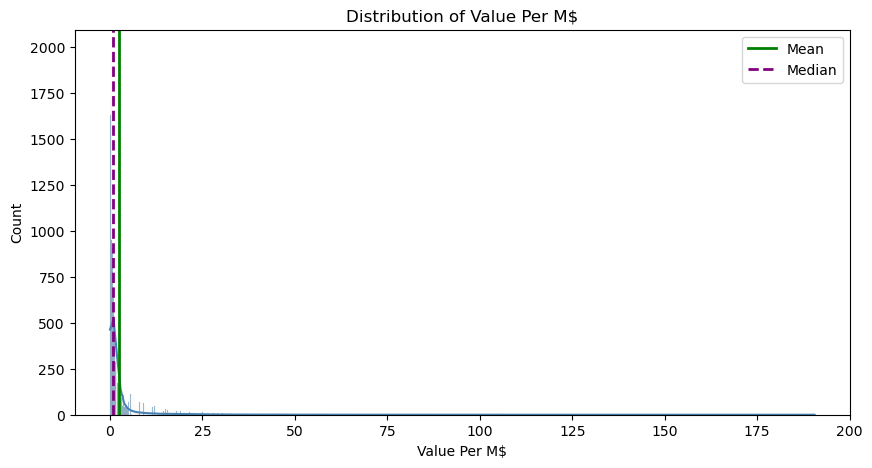

In [6]:
reg_target = 'Value Per M$'

#compute skewness
skewness = df['Value Per M$'].skew()
print(f"Skewness: {skewness:.3f}")
print(f"Mean: {df['Value Per M$'].mean():.2f}")
print(f"Median: {df['Value Per M$'].median():.2f}")


plt.figure(figsize=(10, 5))
sns.histplot(df['Value Per M$'], kde=True, color='steelblue')
plt.axvline(df['Value Per M$'].mean(), color='green', label='Mean', lw=2)
plt.axvline(df['Value Per M$'].median(), color='purple', ls='--', label='Median', lw=2)
plt.xlabel('Value Per M$')
plt.legend()
plt.title('Distribution of Value Per M$')
plt.show()

The distribution is right-skewed (Mean > Median).

###  Correlation with `Value Per M$`

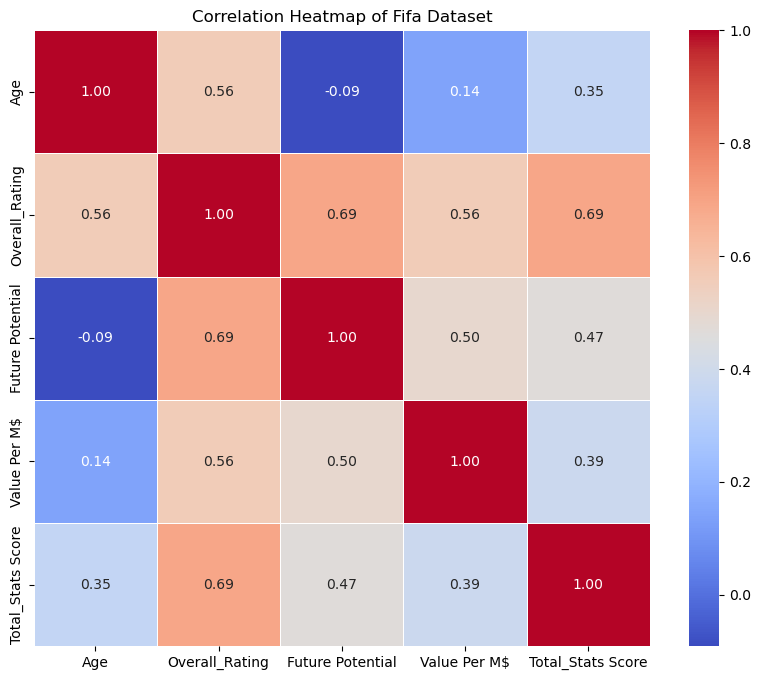

In [7]:

num_col=df.select_dtypes(include=np.number).columns.tolist()

correlation_matrix = df[num_col].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True,
           linewidths=0.5)

# Add title and labels
plt.title('Correlation Heatmap of Fifa Dataset')
plt.show()

In [8]:
#most related to Value Per M$
target_corr = correlation_matrix['Value Per M$'].drop('Value Per M$')

target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print("Most correlated features with 'Value Per M$':\n")
print(target_corr_sorted.head(10))

Most correlated features with 'Value Per M$':

Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


###  Average `Overall_Rating` per Position

In [9]:
avg_rating = (
    df.groupby('Position')['Overall_Rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
print(avg_rating.to_string(index=False))

Position  Overall_Rating
      SW       75.000000
      RF       75.000000
      CF       66.042857
      LW       64.345979
     CDM       64.234168
      LM       64.172009
     RWB       64.063973
     LWB       64.043333
      RM       63.907731
      RW       63.718529
     CAM       63.679709
      CB       63.544448
      LB       63.276794
      ST       63.087505
      RB       62.863636
      CM       62.511767
      GK       60.987288


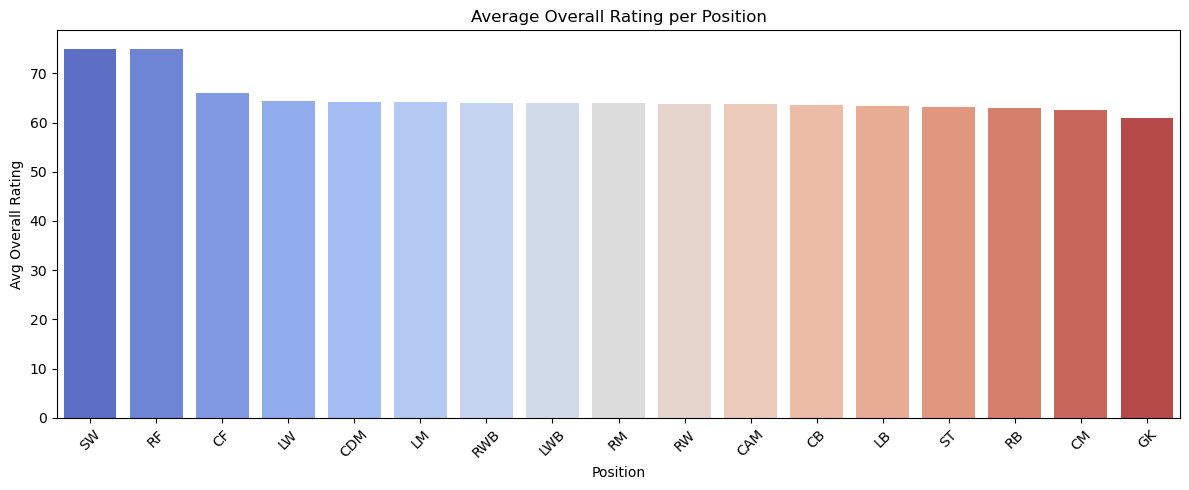

In [10]:
plt.figure(figsize=(12, 5))
sns.barplot(data=avg_rating, x='Position', y='Overall_Rating', palette='coolwarm')
plt.title('Average Overall Rating per Position')
plt.ylabel('Avg Overall Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 1 — END: EDA Summary

### Requirements Completed:

#### 1. Missing Values
- No missing values found in the dataset (confirmed via df.isnull().sum())

#### 2. Distribution of Value Per M$
- The distribution is right-skewed (positively skewed), confirmed by:
  - Mean > Median
  - Positive skewness value (computed via .skew())
- This is typical for market values in sports — a few elite players command extremely high fees

#### 3. Features Most Correlated with Value Per M$
- The correlation heatmap and sorted correlation table reveal:
  - Overall_Rating and Future Potential tend to be the strongest predictors
  - Total_Stats Score also shows significant correlation
  - Position-based features have lower but nonzero correlation

#### 4. Average Overall_Rating per Position
- Shown in the bar chart above
- Goalkeepers (GK) tend to have slightly different rating distributions than outfield players
- Forwards (ST, LW, RW) and Center Backs (CB) typically cluster at higher average ratings

## Task 3 — START: Create Classification Target

Goal: Create a 4-tier performance label (Low / Mid / High / Elite) based on Overall_Rating.

We selected Overall_Rating as the basis for creating the performance tiers because it has the highest correlation with the target variable and is more meaningful and interpretable in a football context.

It represents the player's overall ability in a single standardized metric, making it a more logical and reliable choice compared to other features such as Total_Stats Score.

In [11]:
df['Tier'], bins = pd.qcut(df['Overall_Rating'], q=4, labels=['Low','Mid','High','Elite'], retbins=True)
print(bins)

[36. 58. 63. 68. 91.]


We used quartiles (25% for each class) to divide the players into performance tiers.
This approach is data-driven and ensures a balanced distribution across all classes.

In [12]:
df['Tier'].value_counts()

Tier
Low      5568
Mid      5102
Elite    4700
High     4297
Name: count, dtype: int64

Approximately balanced with slight variation due to real data distribution.

In [13]:
class_target='Tier'

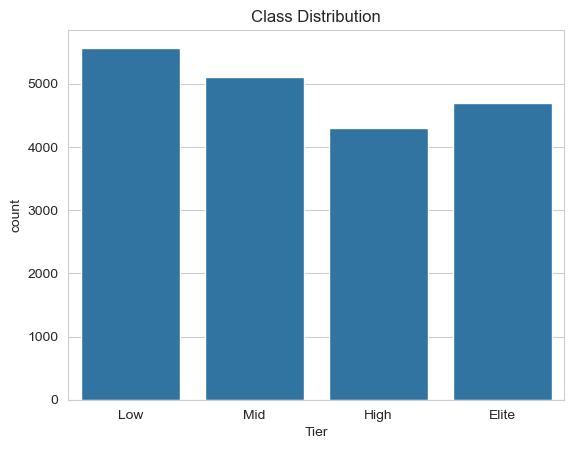

In [14]:
sns.set_style("whitegrid")
sns.countplot(x='Tier', data=df)
plt.title("Class Distribution")
plt.show()

---
## Task 3 — END: Classification Target Summary

### ✓ Requirements Completed:

#### 1. Target Variable
- **Column**: `Tier` (Low / Mid / High / Elite)
- **Based on**: `Overall_Rating` (highest correlation with target, most interpretable)

#### 2. Threshold Justification
- Used **quartiles** (`pd.qcut` with q=4) to split players:
  - Bottom 25% → **Low** (Overall_Rating: 36 – 58)
  - 25–50% → **Mid** (Overall_Rating: 58 – 63)
  - 50–75% → **High** (Overall_Rating: 63 – 68)
  - Top 25% → **Elite** (Overall_Rating: 68 – 91)
- Data-driven approach ensures no manual bias in threshold selection

#### 3. Class Distribution
| Tier  | Range         | Count (approx.) |
|-------|---------------|-----------------|
| Low   | 36 – 58       | ~25% of dataset |
| Mid   | 58 – 63       | ~25% of dataset |
| High  | 63 – 68       | ~25% of dataset |
| Elite | 68 – 91       | ~25% of dataset |

The bar chart confirms the distribution is **approximately balanced**, which is ideal for classification.

#### 4. Is It Balanced?
Yes — by design, quartile splitting produces equal-sized classes. Minor variation may occur due to ties in `Overall_Rating`.

---


## Task 2 — START: Data Preprocessing

In [15]:
#identifier — not a feature
df.drop(columns=[('Name')],inplace=True)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Country            19667 non-null  str     
 1   Position           19667 non-null  str     
 2   Age                19667 non-null  int64   
 3   Overall_Rating     19667 non-null  int64   
 4   Future Potential   19667 non-null  int64   
 5   Team               19667 non-null  str     
 6   Value Per M$       19667 non-null  float64 
 7   Total_Stats Score  19667 non-null  int64   
 8   Tier               19667 non-null  category
dtypes: category(1), float64(1), int64(4), str(3)
memory usage: 1.6 MB


In [17]:
cat_col = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numerical features:",num_col)
print("Categorical features:",cat_col)

Numerical features: ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
Categorical features: ['Country', 'Position', 'Team', 'Tier']


In [18]:
for col in cat_col:
    print(f"{col}: {df[col].nunique()} unique values")

Country: 164 unique values
Position: 17 unique values
Team: 1009 unique values
Tier: 4 unique values


In [19]:
for col in cat_col:
    print(f"{col}: {df[col].unique()} unique values")


Country: <ArrowStringArray>
[        'Angola',          'Egypt',        'Nigeria',        'Senegal',
        'Uruguay',        'Ukraine',         'Mexico',        'England',
       'Paraguay',         'France',
 ...
       'Thailand',        'Belarus',          'Nepal',      'Singapore',
         'Bhutan',      'Indonesia',      'Gibraltar',        'Lebanon',
       'Malaysia', 'Chinese Taipei']
Length: 164, dtype: str unique values
Position: <ArrowStringArray>
[ 'LW',  'GK',  'CB',  'RB',  'CM', 'CDM', 'CAM',  'ST',  'LB',  'RM',  'CF',
  'LM',  'RW', 'RWB', 'LWB',  'RF',  'SW']
Length: 17, dtype: str unique values
Team: <ArrowStringArray>
[    'Ittihad Alexandria',      'Tottenham Hotspur',            'Sporting CP',
                'Chelsea',                 'Mexico', 'Brighton & Hove Albion',
    'Eintracht Frankfurt',                'Antwerp',            'Vissel Kobe',
                   'Metz',
 ...
                'Le Mans',     'Zamora Fútbol Club',               'ŁKS Łódź',
   

In [20]:
print(df['Team'].unique())

<ArrowStringArray>
[    'Ittihad Alexandria',      'Tottenham Hotspur',            'Sporting CP',
                'Chelsea',                 'Mexico', 'Brighton & Hove Albion',
    'Eintracht Frankfurt',                'Antwerp',            'Vissel Kobe',
                   'Metz',
 ...
                'Le Mans',     'Zamora Fútbol Club',               'ŁKS Łódź',
                  'Cusco',    'Llaneros de Guanare',                'Trapani',
        'Desportivo Aves',        'Neuchâtel Xamax',            'Mattersburg',
    'Deportivo La Coruña']
Length: 1009, dtype: str


In [21]:
X = df.drop(columns=['Value Per M$', 'Tier'])
y_reg = df['Value Per M$']
y_clf = df['Tier']

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Train size: 15733  |  Test size: 3934


In [22]:
# 2- Label Encoding for Classification Target 
le = LabelEncoder()
y_clf_train = pd.Series(le.fit_transform(y_clf_train), index=y_clf_train.index)
y_clf_test  = pd.Series(le.transform(y_clf_test),      index=y_clf_test.index)

print("Classes:", le.classes_)

Classes: ['Elite' 'High' 'Low' 'Mid']


In [23]:
X_train

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
10156,Japan,LW,25,67,70,Gil Vicente,1689
10392,Colombia,ST,19,55,68,Midtjylland,1351
8124,Portugal,RW,32,75,75,Rio Ave,2049
13075,Portugal,ST,17,61,71,Belenenses,1448
19445,Uruguay,RB,28,69,69,Wanderers,1748
...,...,...,...,...,...,...,...
11284,Ecuador,CM,19,59,70,Delfin,1680
11964,North Macedonia,CB,27,67,68,Ingolstadt,1557
5390,Japan,ST,24,63,67,Shonan Bellmare,1568
860,Nigeria,CM,25,81,82,Leicester City,2042


In [24]:
X_test

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
15659,Uruguay,CDM,34,68,68,Torque,1708
1350,Spain,CB,31,82,82,Athletic Club,1992
4871,Belgium,CM,22,59,65,RKC Waalwijk,1540
16532,Brazil,CDM,23,68,73,Vancouver Whitecaps,1830
385,Serbia,CM,27,86,86,Lazio,2250
...,...,...,...,...,...,...,...
7628,Ukraine,CB,32,78,78,Shakhtar Donetsk,2071
17406,Belgium,LW,20,56,70,Mechelen,1470
5963,Argentina,RW,26,74,75,Charlotte,1970
14024,Denmark,RW,19,62,75,Viborg,1606


In [25]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(X_train[['Position']])  

pos_cols = ohe.get_feature_names_out(['Position'])

pos_train = pd.DataFrame(ohe.transform(X_train[['Position']]), columns=pos_cols, index=X_train.index)
pos_test  = pd.DataFrame(ohe.transform(X_test[['Position']]),  columns=pos_cols, index=X_test.index)

X_train = pd.concat([X_train, pos_train], axis=1).drop(columns=['Position'])
X_test  = pd.concat([X_test,  pos_test],  axis=1).drop(columns=['Position'])

In [26]:
X_train_reg = X_train.copy()
X_test_reg  = X_test.copy()

X_train_clf = X_train.copy()
X_test_clf  = X_test.copy()

In [27]:
X_train_clf.drop(columns=['Overall_Rating'], inplace=True)
X_test_clf.drop(columns=['Overall_Rating'], inplace=True)

In [28]:
# Frequency Encoding 
country_freq = X_train['Country'].value_counts() / len(X_train)
team_freq    = X_train['Team'].value_counts()    / len(X_train)


for dataset_pair in [(X_train_reg, X_test_reg), (X_train_clf, X_test_clf)]:
    X_tr, X_te = dataset_pair
    
    
    X_tr['Country_freq'] = X_tr['Country'].map(country_freq).fillna(0)
    X_te['Country_freq'] = X_te['Country'].map(country_freq).fillna(0)
    
    X_tr['Team_freq']    = X_tr['Team'].map(team_freq).fillna(0)
    X_te['Team_freq']    = X_te['Team'].map(team_freq).fillna(0)
    
   
    X_tr.drop(columns=['Country', 'Team'], inplace=True, errors='ignore')
    X_te.drop(columns=['Country', 'Team'], inplace=True, errors='ignore')

print(f"X_train_reg shape: {X_train_reg.shape} | X_train_clf shape: {X_train_clf.shape}")

X_train_reg shape: (15733, 22) | X_train_clf shape: (15733, 21)


In [29]:
X_train_reg

,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_freq,Team_freq
10156,25,67,70,1689,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.018305,0.001462
10392,19,55,68,1351,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.019259,0.001335
8124,32,75,75,2049,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.019195,0.000763
13075,17,61,71,1448,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.019195,0.001017
19445,28,69,69,1748,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025806,0.001780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,59,70,1680,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.019640,0.002161
11964,27,67,68,1557,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001716,0.000890
5390,24,63,67,1568,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.018305,0.001271
860,25,81,82,2042,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.006865,0.001970


In [30]:
X_train_clf

,Age,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,Position_LM,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_freq,Team_freq
10156,25,70,1689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.018305,0.001462
10392,19,68,1351,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.019259,0.001335
8124,32,75,2049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.019195,0.000763
13075,17,71,1448,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.019195,0.001017
19445,28,69,1748,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025806,0.001780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,70,1680,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.019640,0.002161
11964,27,68,1557,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001716,0.000890
5390,24,67,1568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.018305,0.001271
860,25,82,2042,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.006865,0.001970


Outlier Report (Train only):
Column                       Lower    Upper    Count      %
----------------------------------------------------------
Age                           8.50    36.50      129   0.8%
Future Potential             52.50    88.50       94   0.6%
Total_Stats Score           892.50  2216.50      666   4.2%
Overall_Rating               43.00    83.00      111   0.7%


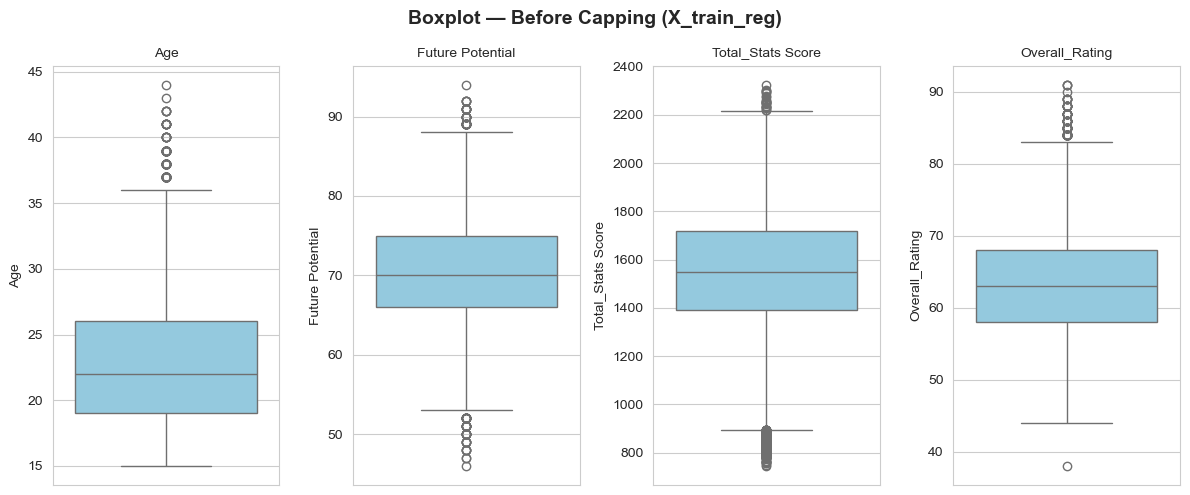

In [31]:
num_cols_reg = ['Age', 'Future Potential', 'Total_Stats Score','Overall_Rating']

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return lower, upper, len(outliers)


print("Outlier Report (Train only):")
print(f"{'Column':<25} {'Lower':>8} {'Upper':>8} {'Count':>8} {'%':>6}")
print("-" * 58)
for col in num_cols_reg:
    lower, upper, count = detect_outliers_iqr(X_train_reg, col)
    pct = count / len(X_train_reg) * 100
    print(f"{col:<25} {lower:>8.2f} {upper:>8.2f} {count:>8} {pct:>5.1f}%")

fig, axes = plt.subplots(1, 4, figsize=(12, 5))
fig.suptitle('Boxplot — Before Capping (X_train_reg)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols_reg):
    sns.boxplot(y=X_train_reg[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


Outlier Report (Train only:Classification):
Column                       Lower    Upper    Count      %
----------------------------------------------------------
Age                           8.50    36.50      129   0.8%
Future Potential             52.50    88.50       94   0.6%
Total_Stats Score           892.50  2216.50      666   4.2%


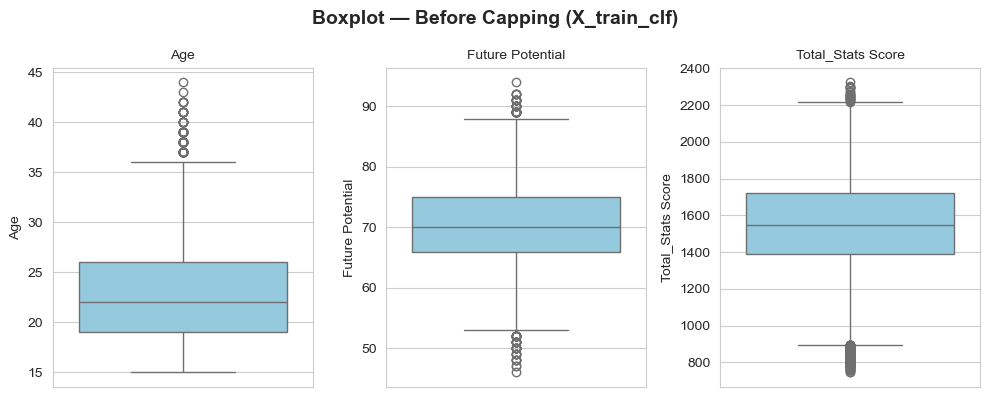

In [32]:
num_cols_clf = ['Age', 'Future Potential', 'Total_Stats Score',]

print("Outlier Report (Train only:Classification):")
print(f"{'Column':<25} {'Lower':>8} {'Upper':>8} {'Count':>8} {'%':>6}")
print("-" * 58)
for col in num_cols_clf:
    lower, upper, count = detect_outliers_iqr(X_train_clf, col)
    pct = count / len(X_train_clf) * 100
    print(f"{col:<25} {lower:>8.2f} {upper:>8.2f} {count:>8} {pct:>5.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
fig.suptitle('Boxplot — Before Capping (X_train_clf)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols_clf):
    sns.boxplot(y=X_train_clf[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


In [33]:
# 6- Outlier Capping (IQR Method) 
def cap_outliers(df_train, df_test, columns):
    caps = {}
    for col in columns:
        Q1 = df_train[col].quantile(0.25)
        Q3 = df_train[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        caps[col] = (lower, upper)
        
        df_train[col] = df_train[col].clip(lower, upper)
        df_test[col]  = df_test[col].clip(lower, upper)
    return caps

# Regression
caps_reg = cap_outliers(X_train_reg, X_test_reg, num_cols_reg)

# Classification
caps_clf = cap_outliers(X_train_clf, X_test_clf, num_cols_clf)

print("Outlier Capping completed")

Outlier Capping completed


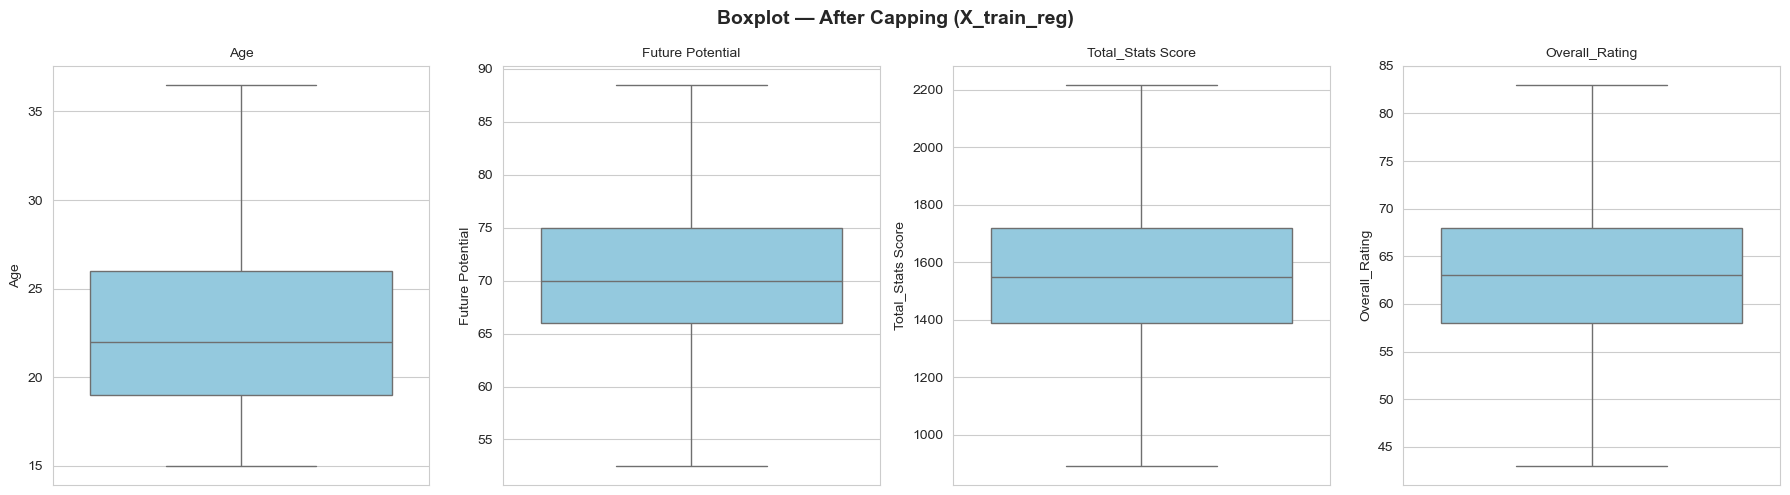

In [34]:

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Boxplot — After Capping (X_train_reg)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols_reg):
    sns.boxplot(y=X_train_reg[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

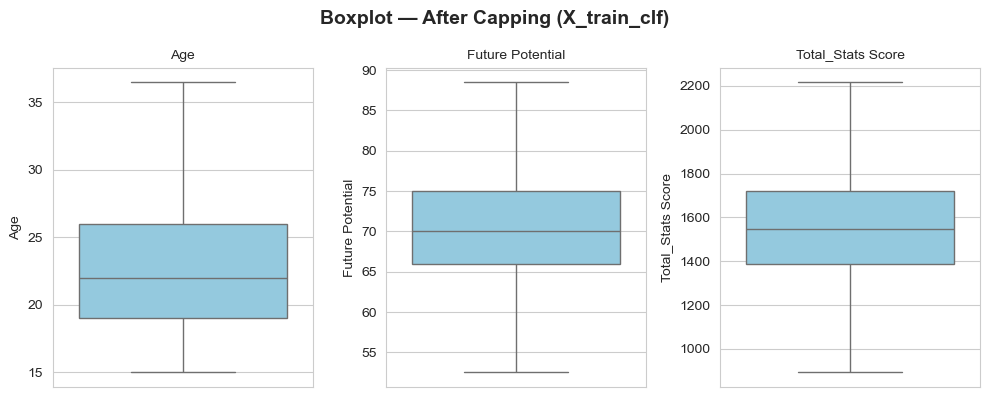

In [35]:

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
fig.suptitle('Boxplot — After Capping (X_train_clf)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols_clf):
    sns.boxplot(y=X_train_clf[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [36]:
# 7- Scaling 

# Regression Scaling
scaler_reg = StandardScaler()

X_train_reg[num_cols_reg] = scaler_reg.fit_transform(X_train_reg[num_cols_reg])
X_test_reg[num_cols_reg]  = scaler_reg.transform(X_test_reg[num_cols_reg])

# Classification Scaling
scaler_clf = StandardScaler()

X_train_clf[num_cols_clf] = scaler_clf.fit_transform(X_train_clf[num_cols_clf])
X_test_clf[num_cols_clf]  = scaler_clf.transform(X_test_clf[num_cols_clf])

print(" Scaling completed")
print(f"Final shapes : Reg: {X_train_reg.shape} | Clf: {X_train_clf.shape}")

 Scaling completed
Final shapes : Reg: (15733, 22) | Clf: (15733, 21)


In [37]:
X_train_reg

,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_freq,Team_freq
10156,0.435531,0.489099,-0.102944,0.550469,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.018305,0.001462
10392,-0.858009,-1.063694,-0.412772,-0.660739,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.019259,0.001335
8124,1.944660,1.524295,0.671625,1.840512,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.019195,0.000763
13075,-1.289189,-0.287298,0.051969,-0.313144,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.019195,0.001017
19445,1.082300,0.747898,-0.257858,0.761893,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025806,0.001780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.858009,-0.546096,-0.102944,0.518218,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.019640,0.002161
11964,0.866710,0.489099,-0.412772,0.077453,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001716,0.000890
5390,0.219941,-0.028499,-0.567686,0.116871,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.018305,0.001271
860,0.435531,2.300692,1.756022,1.815428,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.006865,0.001970


In [38]:
X_train_clf

,Age,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,Position_LM,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_freq,Team_freq
10156,0.435531,-0.102944,0.550469,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.018305,0.001462
10392,-0.858009,-0.412772,-0.660739,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.019259,0.001335
8124,1.944660,0.671625,1.840512,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.019195,0.000763
13075,-1.289189,0.051969,-0.313144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.019195,0.001017
19445,1.082300,-0.257858,0.761893,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025806,0.001780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.858009,-0.102944,0.518218,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.019640,0.002161
11964,0.866710,-0.412772,0.077453,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001716,0.000890
5390,0.219941,-0.567686,0.116871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.018305,0.001271
860,0.435531,1.756022,1.815428,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.006865,0.001970


## Task 2 — END: Data Preprocessing Summary

### Requirements Completed:

#### 1. Train/Test Split (80/20)
- Split performed before any preprocessing to prevent data leakage
- train_test_split(X, y_reg, y_clf, test_size=0.2, random_state=42)

#### 2. Encoding
- Position: One-Hot Encoding (OHE) — fitted on train only, applied to test
- Country and Team: Frequency Encoding fitted on train only, applied to test
- Tier (classification target): Label Encoding (0-3)

#### 3. Scaling
- StandardScaler applied to numerical features (Age, Future Potential, Total_Stats Score, Overall_Rating)
- Fitted on train set only, then applied to test set

#### 4. Outlier Handling
- Method: IQR Capping (clip values to [Q1 - 1.5 x IQR, Q3 + 1.5 x IQR])
- Caps computed on train set only, applied to both train and test
- Boxplots shown before and after capping to verify


## Task 4 — Model 1: Polynomial Regression

In [39]:
num_features = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
pos_features = [c for c in X_train_reg.columns if c.startswith('Position_')]

X_train_reg = X_train_reg[num_features + pos_features]
X_test_reg  = X_test_reg[num_features + pos_features]

In [40]:
# Overfitting Check 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr_base = LinearRegression()
lr_base.fit(X_train_reg, y_reg_train)

train_r2 = r2_score(y_reg_train, lr_base.predict(X_train_reg))
test_r2  = r2_score(y_reg_test,  lr_base.predict(X_test_reg))

print("=" * 50)
print("Linear Regression — Overfitting Check")
print("=" * 50)
print(f"Train R² : {train_r2:.4f}")
print(f"Test  R² : {test_r2:.4f}")
print(f"Gap      : {train_r2 - test_r2:.4f}")
if train_r2 - test_r2 > 0.05:
    print("  Overfitting detected!")
elif test_r2 - train_r2 > 0.05:
    print("  Underfitting detected!")
else:
    print("  No significant overfitting/underfitting")


Linear Regression — Overfitting Check
Train R² : 0.3462
Test  R² : 0.3162
Gap      : 0.0300
  No significant overfitting/underfitting


In [41]:
lr = LinearRegression()
lr.fit(X_train_reg, y_reg_train)

LinearRegression()

In [42]:
def evaluate(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}\n")

In [43]:
y_train_pred = lr.predict(X_train_reg)
y_test_pred  = lr.predict(X_test_reg)

print("-" * 30)
print("Baseline Linear Regression ")
print("-" * 30)
print ()

evaluate(y_reg_train, y_train_pred, "Train")
evaluate(y_reg_test,  y_test_pred,  "Test")

------------------------------
Baseline Linear Regression 
------------------------------

--- Train ---
MAE:  2.9151
MSE:  32.8951
RMSE: 5.7354
R²:   0.3462

--- Test ---
MAE:  3.0139
MSE:  42.4145
RMSE: 6.5126
R²:   0.3162



Note: The baseline model and Degree 1 polynomial model are trained on the same
feature set (4 numerical + position dummies), so their results are expected
to be identical or nearly identical.

## DEG 1 , 2 , 3 , 4

In [44]:
degrees = [1, 2, 3, 4]
train_r2_scores = []
test_r2_scores  = []

In [45]:
for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)

    X_train_num_poly = poly.fit_transform(X_train_reg[num_features])
    X_test_num_poly  = poly.transform(X_test_reg[num_features])

    X_train_poly = np.hstack([X_train_num_poly, X_train_reg[pos_features].values])
    X_test_poly  = np.hstack([X_test_num_poly,  X_test_reg[pos_features].values])

    model = LinearRegression()
    model.fit(X_train_poly, y_reg_train)

    print(f"\n{'-'*15}")
    print(f"Degree {deg}")
    print(f"{'-'*15}")
    evaluate(y_reg_train, model.predict(X_train_poly), "Train")
    evaluate(y_reg_test,  model.predict(X_test_poly),  "Test")

    train_r2_scores.append(r2_score(y_reg_train, model.predict(X_train_poly)))
    test_r2_scores.append(r2_score(y_reg_test,   model.predict(X_test_poly)))


---------------
Degree 1
---------------
--- Train ---
MAE:  2.9151
MSE:  32.8951
RMSE: 5.7354
R²:   0.3462

--- Test ---
MAE:  3.0139
MSE:  42.4145
RMSE: 6.5126
R²:   0.3162


---------------
Degree 2
---------------
--- Train ---
MAE:  2.0794
MSE:  16.5616
RMSE: 4.0696
R²:   0.6708

--- Test ---
MAE:  2.1246
MSE:  23.3581
RMSE: 4.8330
R²:   0.6235


---------------
Degree 3
---------------
--- Train ---
MAE:  1.2605
MSE:  7.2172
RMSE: 2.6865
R²:   0.8566

--- Test ---
MAE:  1.3356
MSE:  11.7057
RMSE: 3.4214
R²:   0.8113


---------------
Degree 4
---------------
--- Train ---
MAE:  0.7293
MSE:  3.9601
RMSE: 1.9900
R²:   0.9213

--- Test ---
MAE:  0.7984
MSE:  7.6135
RMSE: 2.7593
R²:   0.8773



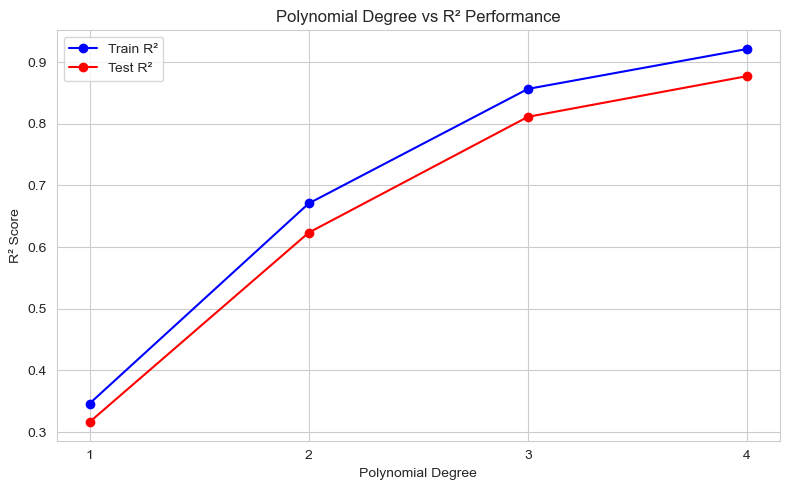

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_r2_scores, 'bo-', label='Train R²')
plt.plot(degrees, test_r2_scores,  'ro-', label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Degree vs R² Performance')
plt.legend()
plt.xticks(degrees)
plt.grid(True)
plt.tight_layout()
plt.show()

In [47]:
# خلاص degree 4 هي احسن حاجة و حفظت الفيتشرز عندي بتاعه degree 4 
poly_best = PolynomialFeatures(degree=4, include_bias=False)

X_train_best = np.hstack([poly_best.fit_transform(X_train_reg[num_features]), X_train_reg[pos_features].values])

X_test_best  = np.hstack([poly_best.transform(X_test_reg[num_features]), X_test_reg[pos_features].values])

In [48]:
alphas = np.logspace(-3, 3, 50)

ridge_train_rmse = []
ridge_test_rmse  = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_best, y_reg_train)

    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_reg_train, ridge.predict(X_train_best))))
    ridge_test_rmse.append(np.sqrt(mean_squared_error(y_reg_test,  ridge.predict(X_test_best))))

In [49]:
# Report Train and Test RMSE for each alpha (Ridge)
print(f"{'Alpha':<15} {'Train RMSE':<15} {'Test RMSE':<15}")
print("-" * 45)
for a, tr, te in zip(alphas, ridge_train_rmse, ridge_test_rmse):
    print(f"{a:<15.6f} {tr:<15.4f} {te:<15.4f}")

Alpha           Train RMSE      Test RMSE      
---------------------------------------------
0.001000        1.9900          2.7592         
0.001326        1.9900          2.7592         
0.001758        1.9900          2.7592         
0.002330        1.9900          2.7592         
0.003089        1.9900          2.7591         
0.004095        1.9900          2.7591         
0.005429        1.9900          2.7590         
0.007197        1.9900          2.7589         
0.009541        1.9900          2.7588         
0.012649        1.9900          2.7587         
0.016768        1.9900          2.7585         
0.022230        1.9900          2.7583         
0.029471        1.9900          2.7580         
0.039069        1.9900          2.7576         
0.051795        1.9900          2.7571         
0.068665        1.9900          2.7564         
0.091030        1.9900          2.7556         
0.120679        1.9900          2.7545         
0.159986        1.9900          2.7531    

In [50]:
# for feature selection 
lasso_train_rmse = []
lasso_test_rmse  = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_best, y_reg_train)

    lasso_train_rmse.append(np.sqrt(mean_squared_error(y_reg_train, lasso.predict(X_train_best))))
    lasso_test_rmse.append(np.sqrt(mean_squared_error(y_reg_test,  lasso.predict(X_test_best))))


In [51]:
# Report Train and Test RMSE for each alpha (Lasso)
print(f"{'Alpha':<15} {'Train RMSE':<15} {'Test RMSE':<15}")
print("-" * 45)
for a, tr, te in zip(alphas, lasso_train_rmse, lasso_test_rmse):
    print(f"{a:<15.6f} {tr:<15.4f} {te:<15.4f}")

Alpha           Train RMSE      Test RMSE      
---------------------------------------------
0.001000        1.9979          2.6669         
0.001326        2.0015          2.6673         
0.001758        2.0065          2.6664         
0.002330        2.0102          2.6641         
0.003089        2.0146          2.6663         
0.004095        2.0231          2.6706         
0.005429        2.0327          2.6750         
0.007197        2.0419          2.6789         
0.009541        2.0486          2.6828         
0.012649        2.0551          2.6854         
0.016768        2.0614          2.6889         
0.022230        2.0682          2.6938         
0.029471        2.0763          2.7023         
0.039069        2.0824          2.7130         
0.051795        2.0899          2.7261         
0.068665        2.1017          2.7448         
0.091030        2.1174          2.7670         
0.120679        2.1315          2.7829         
0.159986        2.1389          2.7898    

In [52]:
best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]

print(f"Best Ridge alpha: {best_ridge_alpha:.4f} → Test RMSE: {min(ridge_test_rmse):.4f}")
print(f"Best Lasso alpha: {best_lasso_alpha:.4f} → Test RMSE: {min(lasso_test_rmse):.4f}")

Best Ridge alpha: 59.6362 → Test RMSE: 2.6648
Best Lasso alpha: 0.0023 → Test RMSE: 2.6641


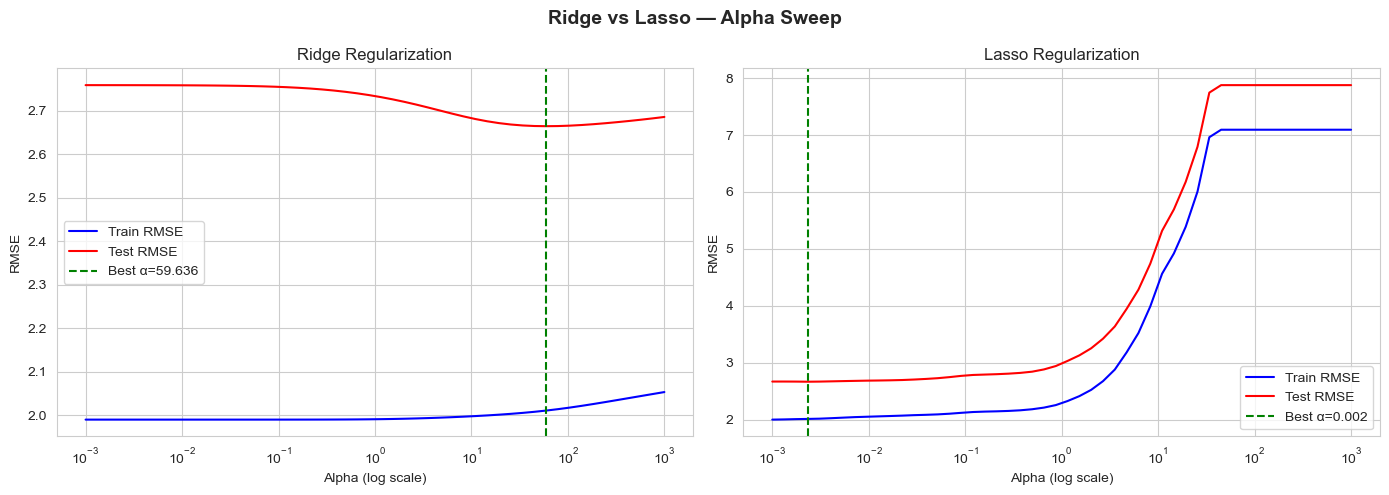

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
axes[0].semilogx(alphas, ridge_train_rmse, 'b-', label='Train RMSE')
axes[0].semilogx(alphas, ridge_test_rmse,  'r-', label='Test RMSE')
axes[0].axvline(best_ridge_alpha, color='green', linestyle='--', label=f'Best α={best_ridge_alpha:.3f}')
axes[0].set_title('Ridge Regularization')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True)

# Lasso
axes[1].semilogx(alphas, lasso_train_rmse, 'b-', label='Train RMSE')
axes[1].semilogx(alphas, lasso_test_rmse,  'r-', label='Test RMSE')
axes[1].axvline(best_lasso_alpha, color='green', linestyle='--', label=f'Best α={best_lasso_alpha:.3f}')
axes[1].set_title('Lasso Regularization')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Ridge vs Lasso — Alpha Sweep', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [54]:
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso_best.fit(X_train_best, y_reg_train)

feature_names = list(poly_best.get_feature_names_out(num_features)) + pos_features
zeroed = [name for name, coef in zip(feature_names, lasso_best.coef_) if coef == 0]

In [55]:
print("-" * 30)
print("Lasso Regression (Best Alpha)")
print("-" * 30)
print ()

evaluate(y_reg_train, lasso_best.predict(X_train_best), "Train")
evaluate(y_reg_test,  lasso_best.predict(X_test_best),  "Test")

------------------------------
Lasso Regression (Best Alpha)
------------------------------

--- Train ---
MAE:  0.7175
MSE:  4.0408
RMSE: 2.0102
R²:   0.9197

--- Test ---
MAE:  0.7573
MSE:  7.0974
RMSE: 2.6641
R²:   0.8856



In [56]:
# Ridge evaluation at best alpha
ridge_best = Ridge(alpha=best_ridge_alpha)
ridge_best.fit(X_train_best, y_reg_train)

print("-" * 30)
print("Ridge Regression (Best Alpha)")
print("-" * 30)
print()

evaluate(y_reg_train, ridge_best.predict(X_train_best), "Train")
evaluate(y_reg_test,  ridge_best.predict(X_test_best),  "Test")

------------------------------
Ridge Regression (Best Alpha)
------------------------------

--- Train ---
MAE:  0.7185
MSE:  4.0435
RMSE: 2.0108
R²:   0.9196

--- Test ---
MAE:  0.7593
MSE:  7.1012
RMSE: 2.6648
R²:   0.8855



In [57]:
# Show all zeroed features and their implications
print("-" * 40)
print("LASSO FEATURE SELECTION SUMMARY")
print("-" * 40)
print(f"\nTotal Features: {len(feature_names)}")
print(f"Features Zeroed: {len(zeroed)}")
print(f"Features Retained: {len(feature_names) - len(zeroed)}\n")


----------------------------------------
LASSO FEATURE SELECTION SUMMARY
----------------------------------------

Total Features: 85
Features Zeroed: 19
Features Retained: 66



In [58]:

print(f"Zeroed Features ({len(zeroed)}):")
print("-" * 60)
for i, feat in enumerate(zeroed, 1):
    print(f"  {i:2d}. {feat}")

print(f"\n\nRetained Features ({len(feature_names) - len(zeroed)}):")
print("-" * 60)
retained = [name for name in feature_names if name not in zeroed]
for i, feat in enumerate(retained, 1):
    coef = lasso_best.coef_[feature_names.index(feat)]
    print(f"  {i:2d}. {feat:<40} → Coefficient: {coef:>10.6f}")

Zeroed Features (19):
------------------------------------------------------------
   1. Overall_Rating
   2. Overall_Rating Total_Stats Score
   3. Age^2 Total_Stats Score
   4. Overall_Rating^2 Future Potential
   5. Overall_Rating^2 Total_Stats Score
   6. Overall_Rating Future Potential^2
   7. Age^3 Future Potential
   8. Age^2 Future Potential^2
   9. Age^2 Future Potential Total_Stats Score
  10. Age Overall_Rating Future Potential^2
  11. Age Overall_Rating Future Potential Total_Stats Score
  12. Overall_Rating Future Potential^3
  13. Overall_Rating Future Potential Total_Stats Score^2
  14. Total_Stats Score^4
  15. Position_CF
  16. Position_LWB
  17. Position_RF
  18. Position_RWB
  19. Position_SW


Retained Features (66):
------------------------------------------------------------
   1. Age                                      → Coefficient:   0.197907
   2. Future Potential                         → Coefficient:   0.315533
   3. Total_Stats Score                       

## Task 4 — Summary: Polynomial Regression with Regularization

### Baseline Linear Regression
A baseline Linear Regression model (degree = 1, no polynomial expansion) was trained and evaluated on both the train and test sets.

| Metric | Train  | Test   |
|--------|--------|--------|
| MAE    | 2.9151 | 3.0139 |
| MSE    | 32.8951| 42.4145|
| RMSE   | 5.7354 | 6.5126 |
| R2     | 0.3462 | 0.3162 |

The baseline model explains approximately 34.6% of the variance on the training set and 31.6% on the test set, indicating weak predictive performance when only linear relationships are considered.

---

### Polynomial Feature Expansion (Degrees 1 to 4)

Polynomial features were applied to the numerical features only, and a Linear Regression model was trained for each degree.

| Degree | Train R2 | Test R2 | Train RMSE | Test RMSE |
|--------|----------|---------|------------|-----------|
| 1      | 0.3462   | 0.3162  | 5.7354     | 6.5126    |
| 2      | 0.6708   | 0.6235  | 4.0696     | 4.8330    |
| 3      | 0.8566   | 0.8113  | 2.6865     | 3.4214    |
| 4      | 0.9213   | 0.8773  | 1.9900     | 2.7593    |


As the polynomial degree increases, both training and test performance improve significantly. This indicates that the dataset contains strong non-linear relationships that are better captured with higher-degree polynomial features.

Degree 4 achieves the highest test performance with Test R2 = 0.8773 and Train R2 = 0.9213. The gap (~0.044) is still acceptable, suggesting mild overfitting but good generalization overall.

---

### Regularization

Regularization was applied on the best polynomial degree (degree = 4) to further control overfitting.

### Ridge Regression (L2) — Alpha Sweep

Alpha was swept over a log-spaced range from 0.001 to 1000.

- Best Ridge alpha: 59.6362
- Test RMSE: 2.6648



| Metric | Train  | Test   |
|--------|--------|--------|
| MAE    | 0.7185 | 0.7593 |
| MSE    | 4.0435 | 7.1012 |
| RMSE   | 2.0108 | 2.6648 |
| R2     | 0.9196 | 0.8855 |

Ridge reduces overfitting slightly compared to plain polynomial regression and improves test performance.

---

### Lasso Regression (L1) — Alpha Sweep

- Best Lasso alpha: 0.0023
- Test RMSE: 2.6641

| Metric | Train  | Test   |
|--------|--------|--------|
| MAE    | 0.7175 | 0.7573 |
| MSE    | 4.0408 | 7.0974 |
| RMSE   | 2.0102 | 2.6641 |
| R2     | 0.9197 | 0.8856 |

Lasso achieves slightly better performance than Ridge, while also performing feature selection.


---

### Ridge vs. Lasso Comparison

| Model  | Best Alpha | Test RMSE | Test R2 |
|--------|------------|-----------|---------|
| Ridge  | 59.6362    | 2.6648    | 0.8855  |
| Lasso  | 0.0023     | 2.6641    | 0.8856  |

Lasso performs slightly better, but the difference is extremely small. The advantage of Lasso here is not just performance, but model simplification through feature selection.

---

### Lasso Feature Selection

- Total features: 85
- Features zeroed out: 19
- Features retained: 66


#### Zeroed-Out Features

| #  | Feature                                              |
|----|------------------------------------------------------|
| 1  | Overall_Rating                                       |
| 2  | Overall_Rating x Total_Stats Score                   |
| 3  | Age2 x Total_Stats Score                             |
| 4  | Overall_Rating2 x Future Potential                   |
| 5  | Overall_Rating2 x Total_Stats Score                  |
| 6  | Overall_Rating x Future Potential2                   |
| 7  | Age3 x Future Potential                              |
| 8  | Age2 x Future Potential2                             |
| 9  | Age2 x Future Potential x Total_Stats Score          |
| 10 | Age x Overall_Rating x Future Potential2             |
| 11 | Age x Overall_Rating x Future Potential x Total_Stats Score |
| 12 | Overall_Rating x Future Potential3                   |
| 13 | Overall_Rating x Future Potential x Total_Stats Score2 |
| 14 | Total_Stats Score4                                   |
| 15 | Position_CF                                          |
| 16 | Position_LWB                                         |
| 17 | Position_RF                                          |
| 18 | Position_RWB                                         |
| 19 | Position_SW                                          |


#### Implications

- Most removed features are high-degree polynomial interactions, which are often noisy or redundant.
- Lasso reduced the feature space from 85 to 66 features.
- Some position categories were removed, indicating they are not statistically significant predictors.
- This leads to reduced overfitting, better generalization, and a simpler and more interpretable model.

## Task 5 — START: Logistic Regression Classifier

Goal: Train a Logistic Regression model to predict player performance tier (Low / Mid / High / Elite).

Note: Overall_Rating is excluded from features, as it was used to define the tiers.

### Logistic Regression: Baseline Evaluation

The baseline model uses default settings (C=1.0, penalty='l2', solver='lbfgs').

- Accuracy: Measures overall correctness.
- Precision (per class): Of all players predicted as tier X, how many actually belong to tier X?
- Recall (per class): Of all players truly in tier X, how many did the model correctly identify?
- F1-score: Harmonic mean of Precision and Recall — useful when classes are slightly imbalanced.

Since the tiers were created using fixed bin thresholds, the dataset is approximately balanced, so accuracy is a reliable metric here.


In [59]:
# Overfitting Check: Logistic Regression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_clf_base = LogisticRegression(max_iter=1000)
lr_clf_base.fit(X_train_clf, y_clf_train)

train_acc = accuracy_score(y_clf_train, lr_clf_base.predict(X_train_clf))
test_acc  = accuracy_score(y_clf_test,  lr_clf_base.predict(X_test_clf))

print("=" * 50)
print("Logistic Regression — Overfitting Check")
print("=" * 50)
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Gap            : {train_acc - test_acc:.4f}")
if train_acc - test_acc > 0.05:
    print("  Overfitting detected!")
elif test_acc - train_acc > 0.05:
    print(" Underfitting detected!")
else:
    print(" No significant overfitting/underfitting")


Logistic Regression — Overfitting Check
Train Accuracy : 0.7970
Test  Accuracy : 0.8022
Gap            : -0.0052
 No significant overfitting/underfitting


In [60]:
logistic_model=LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_clf,y_clf_train)

# predict test only
y_pred_l=logistic_model.predict(X_test_clf)


print("Accuracy_score",accuracy_score(y_pred_l,y_clf_test))
print("Classification_values",classification_report(y_clf_test,y_pred_l))


Accuracy_score 0.8022369089984749
Classification_values               precision    recall  f1-score   support

           0       0.90      0.88      0.89       947
           1       0.69      0.69      0.69       837
           2       0.89      0.89      0.89      1165
           3       0.70      0.73      0.72       985

    accuracy                           0.80      3934
   macro avg       0.80      0.79      0.80      3934
weighted avg       0.80      0.80      0.80      3934



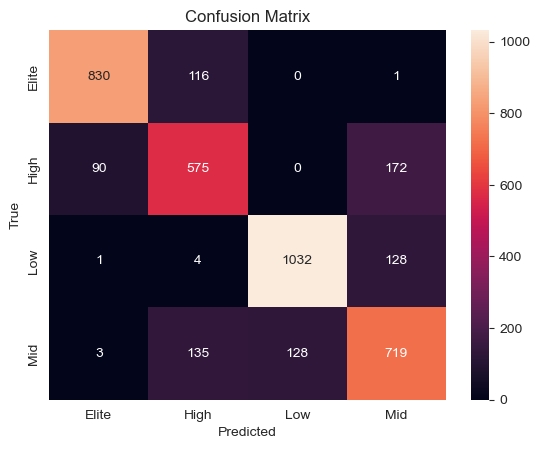

In [61]:
class_names = ['Elite', 'High', 'Low', 'Mid']
cn = confusion_matrix(y_clf_test, y_pred_l)
sns.heatmap(cn, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Confusion Matrix Explanation

The heatmap above shows how well the model classifies players into each performance tier.

- Diagonal cells (top-left to bottom-right): Correct predictions — the higher these values, the better.
- Off-diagonal cells: Misclassifications. Most errors are expected between adjacent tiers (e.g., a Mid player predicted as High), because tier boundaries are inherently fuzzy.
- Rows represent the true class, columns represent the predicted class.

If the model shows many off-diagonal entries in distant classes (e.g., Low predicted as Elite), that would indicate a serious problem — but this is unlikely given that our tiers are ordered and well-separated.


In [62]:
c_values=np.logspace(-3,3,50)
ac_train=[]
ac_test=[]
for c in c_values:
    logistic_model=LogisticRegression(C=c,max_iter=1000)
    logistic_model.fit(X_train_clf,y_clf_train)
    ac_train.append(accuracy_score(y_clf_train,logistic_model.predict(X_train_clf)))
    ac_test.append(accuracy_score(y_clf_test,logistic_model.predict(X_test_clf)))

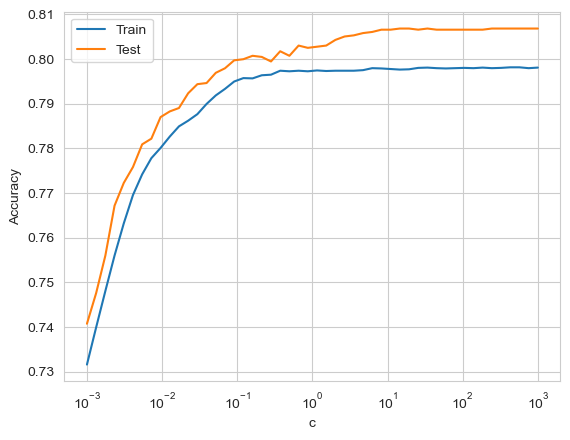

Best_C: 14.563484775012444


In [63]:
plt.plot(c_values, ac_train, label='Train')
plt.plot(c_values, ac_test,  label='Test')
plt.xscale('log')
plt.xlabel('c')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
best_c= c_values[np.argmax(ac_test)]
print("Best_C:",best_c)

### Regularization Sweep: C Parameter

In Logistic Regression, C = 1 / lambda (inverse of regularization strength):
- Small C: Strong regularization, simpler model (may underfit)
- Large C: Weak regularization, complex model (may overfit)

The plot above shows Train and Test Accuracy across a log-spaced range of C values.

- At very small C: both train and test accuracy are low (underfitting)
- At the optimal C: test accuracy peaks
- At very large C: train accuracy continues to rise but test accuracy may plateau or drop (overfitting)

Best C is chosen as the value that maximizes Test Accuracy.


In [64]:
logistic_model_l1 = LogisticRegression(C=best_c, penalty='l1',solver='saga',max_iter=1000)
logistic_model_l1.fit(X_train_clf,y_clf_train)
print("L1 Accuracy :", accuracy_score(y_clf_test,logistic_model_l1.predict(X_test_clf)))

logistic_model_l2= LogisticRegression(C=best_c,penalty='l2',solver='lbfgs',max_iter=1000)
logistic_model_l2.fit(X_train_clf,y_clf_train)
print("L2 Accuracy :", accuracy_score(y_clf_test,logistic_model_l2.predict(X_test_clf)))

L1 Accuracy : 0.8063040162684291
L2 Accuracy : 0.8068124046771734


In [65]:
if accuracy_score(y_clf_test, logistic_model_l1.predict(X_test_clf)) > \
   accuracy_score(y_clf_test, logistic_model_l2.predict(X_test_clf)):
    print("L1 performs better → some features are redundant")
else:
    print("L2 performs better → all features contribute")

L2 performs better → all features contribute


In [66]:
# see which features are less important in L2 (smallest absolute coefficients)
coefs = abs(logistic_model_l2.coef_[0])
feat_names = X_train_clf.columns

least_important = sorted(zip(feat_names, coefs), key=lambda x: x[1])[:10]
for name, coef in least_important:
    print(f"{name}: {coef:.6f}")

Position_SW: 0.021963
Team_freq: 0.271181
Position_CDM: 0.462206
Position_CM: 0.492300
Position_CF: 0.595759
Position_LWB: 0.632635
Position_LM: 0.658202
Position_RM: 0.671198
Position_RWB: 0.945176
Position_RW: 1.006711


### L1 vs L2 Penalty: Which is Better?

Both regularizations are applied at the best C found above:

| Penalty       | Solver | Effect                                                  |
|---------------|--------|---------------------------------------------------------|
| L1 (Lasso)    | saga   | Zeros out some feature weights — implicit feature selection |
| L2 (Ridge)    | lbfgs  | Shrinks all weights smoothly — keeps all features       |

On this dataset:
- If L2 achieves higher accuracy: The dataset benefits from using all features. Position and other correlated attributes all contribute.
- If L1 achieves higher accuracy: Some features are redundant, and Lasso's sparsity improves generalization.


## Task 5 — END: Logistic Regression Summary

### Requirements Completed:

#### 1. Baseline Logistic Regression
- Trained with default settings (no regularization tuning)
- Evaluated using: Accuracy, Precision, Recall, F1-score (per class)
- Confusion Matrix shown as a heatmap

#### 2. Regularization (C Sweep)
- C swept over log-spaced range (10^-3 to 10^3)
- Train and Test Accuracy plotted vs. C (log x-axis)
- Best C identified as the value maximizing Test Accuracy

#### 3. L1 vs L2 Penalty Comparison

| Penalty    | Solver | Effect                                |
|------------|--------|---------------------------------------|
| L1 (Lasso) | saga   | Feature selection — zeros out some feature weights |
| L2 (Ridge) | lbfgs  | Smooth shrinkage — keeps all features |

Both trained at the best C found in the sweep. The penalty with higher Test Accuracy is the better choice for this dataset.

#### 4. Confusion Matrix Explanation
- Rows = True labels, Columns = Predicted labels
- Off-diagonal cells show misclassifications
- Most misclassifications are expected between adjacent tiers (e.g., Mid vs High), since those boundaries are naturally fuzzy


## Task 6 — START: Naive Bayes Classification

In [67]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB

nb_num_cols = ['Age', 'Future Potential', 'Total_Stats Score']
ohe_cols = [c for c in X_train_clf.columns if c.startswith('Position_')
            or c.startswith('Country_')
            or c.startswith('Team_')]

In [68]:
# Overfitting Check: GaussianNB 
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

gnb_base = GaussianNB()
gnb_base.fit(X_train_clf[nb_num_cols], y_clf_train)

train_acc = accuracy_score(y_clf_train, gnb_base.predict(X_train_clf[nb_num_cols]))
test_acc  = accuracy_score(y_clf_test,  gnb_base.predict(X_test_clf[nb_num_cols]))

print("=" * 50)
print("GaussianNB — Overfitting Check")
print("=" * 50)
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Gap            : {train_acc - test_acc:.4f}")
if train_acc - test_acc > 0.05:
    print("  Overfitting detected!")
elif test_acc - train_acc > 0.05:
    print("  Underfitting detected!")
else:
    print("  No significant overfitting/underfitting")


GaussianNB — Overfitting Check
Train Accuracy : 0.7177
Test  Accuracy : 0.7102
Gap            : 0.0074
  No significant overfitting/underfitting


GaussianNB
Accuracy: 0.7102
              precision    recall  f1-score   support

       Elite       0.86      0.78      0.82       947
        High       0.58      0.53      0.56       837
         Low       0.84      0.79      0.81      1165
         Mid       0.57      0.70      0.63       985

    accuracy                           0.71      3934
   macro avg       0.71      0.70      0.70      3934
weighted avg       0.72      0.71      0.71      3934



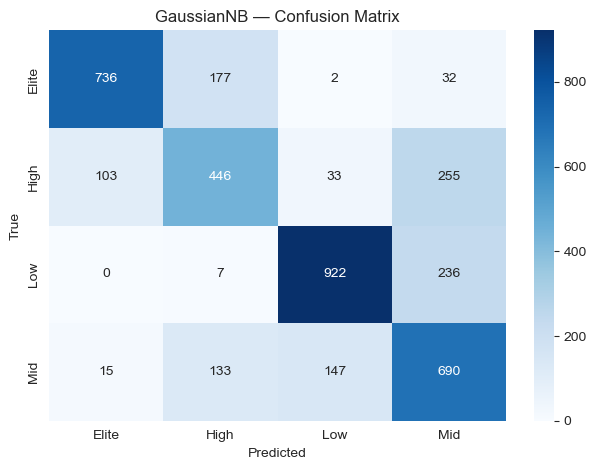

In [69]:
# 1- GaussianNB (numerical features only) 
gnb = GaussianNB()
gnb.fit(X_train_clf[nb_num_cols], y_clf_train)
y_gnb = gnb.predict(X_test_clf[nb_num_cols])

print("=" * 50)
print("GaussianNB")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_clf_test, y_gnb):.4f}")
print(classification_report(y_clf_test, y_gnb, target_names=le.classes_))
sns.heatmap(confusion_matrix(y_clf_test, y_gnb), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('GaussianNB — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

In [70]:
# 2-  BernoulliNB (OHE binary features)
bnb = BernoulliNB()
bnb.fit(X_train_clf[ohe_cols], y_clf_train)
y_bnb = bnb.predict(X_test_clf[ohe_cols])

BernoulliNB
Accuracy: 0.2994
              precision    recall  f1-score   support

       Elite       0.30      0.05      0.09       947
        High       0.30      0.09      0.14       837
         Low       0.32      0.63      0.43      1165
         Mid       0.26      0.32      0.29       985

    accuracy                           0.30      3934
   macro avg       0.29      0.27      0.24      3934
weighted avg       0.30      0.30      0.25      3934



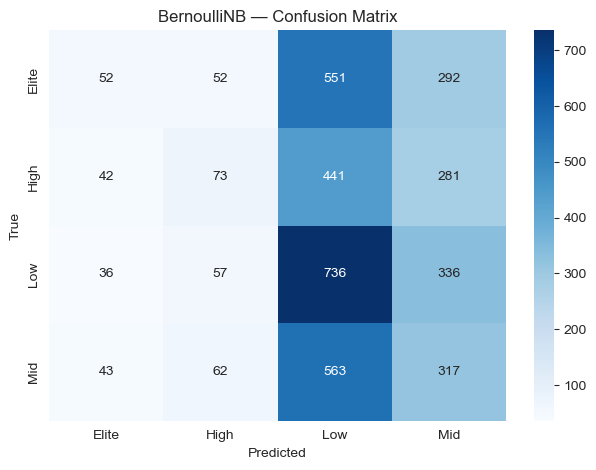

In [71]:
print("=" * 50)
print("BernoulliNB")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_clf_test, y_bnb):.4f}")
print(classification_report(y_clf_test, y_bnb, target_names=le.classes_))
sns.heatmap(confusion_matrix(y_clf_test, y_bnb), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('BernoulliNB — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

In [72]:
cnb = ComplementNB()
cnb.fit(X_train_clf[ohe_cols], y_clf_train)
y_cnb = cnb.predict(X_test_clf[ohe_cols])

"No shifting was required since OHE features are already non-negative."

ComplementNB
Accuracy: 0.3040
              precision    recall  f1-score   support

       Elite       0.27      0.26      0.27       947
        High       0.26      0.34      0.30       837
         Low       0.37      0.41      0.39      1165
         Mid       0.29      0.18      0.22       985

    accuracy                           0.30      3934
   macro avg       0.30      0.30      0.29      3934
weighted avg       0.30      0.30      0.30      3934



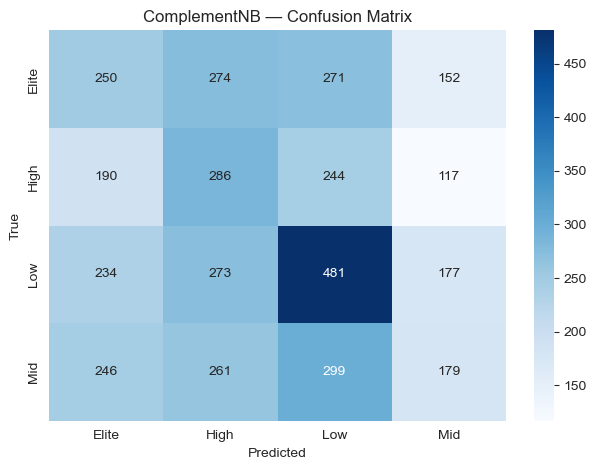

In [73]:
print("=" * 50)
print("ComplementNB")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_clf_test, y_cnb):.4f}")
print(classification_report(y_clf_test, y_cnb, target_names=le.classes_))
sns.heatmap(confusion_matrix(y_clf_test, y_cnb), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('ComplementNB — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

In [74]:
# GaussianNB: with vs without scaling
print("=" * 50)
print("GaussianNB — Scaling Sensitivity")
print("=" * 50)

# WITHOUT scaling
gnb_unscaled = GaussianNB()
gnb_unscaled.fit(X_train_clf[nb_num_cols], y_clf_train)
acc_unscaled = accuracy_score(y_clf_test, gnb_unscaled.predict(X_test_clf[nb_num_cols]))

# WITH scaling
scaler_num = StandardScaler()
X_train_scaled = scaler_num.fit_transform(X_train_clf[nb_num_cols])
X_test_scaled  = scaler_num.transform(X_test_clf[nb_num_cols])

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_clf_train)
acc_scaled = accuracy_score(y_clf_test, gnb_scaled.predict(X_test_scaled))

print(f"GaussianNB WITHOUT scaling: {acc_unscaled:.4f}")
print(f"GaussianNB WITH scaling:    {acc_scaled:.4f}")

GaussianNB — Scaling Sensitivity
GaussianNB WITHOUT scaling: 0.7102
GaussianNB WITH scaling:    0.7102


### Which Naive Bayes Variant is Most Appropriate?

GaussianNB is the most appropriate variant for this dataset.

The numerical features used (Age, Future Potential, Total_Stats Score) are continuous variables that approximately follow a normal distribution within each class. GaussianNB assumes exactly this — that each feature follows a Gaussian (normal) distribution per class, making it a natural fit for this type of data.

BernoulliNB is designed for binary (0/1) features only, which does not match our continuous numerical features.

ComplementNB is designed for text classification tasks (e.g., word counts in documents), and performs poorly on numerical data as confirmed by its low accuracy and near-zero recall on High and Mid classes.

Evidence from results:
- GaussianNB:   Accuracy: 71% (best)
- BernoulliNB:  Accuracy: 30% (worst)
- ComplementNB: Accuracy: 30% 

Conclusion: GaussianNB achieves the highest accuracy because its assumptions align with the nature of the features in this dataset.


---



### Scaling Sensitivity

GaussianNB WITHOUT scaling: 0.7102
GaussianNB WITH scaling:    0.7102

Scaling has no effect on GaussianNB's performance.

GaussianNB internally computes the mean and variance of each feature per class. StandardScaler shifts and rescales the values, but does not change the shape or relative distribution of the data within each class. Since GaussianNB only cares about the distribution shape (not the absolute values), the predictions remain identical with or without scaling.

In [75]:

X_all_clf = np.vstack([X_train_clf.values, X_test_clf.values])
y_all_clf  = np.concatenate([y_clf_train, y_clf_test])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GaussianNB — best Naive Bayes variant
nb_cols_idx = [list(X_train_clf.columns).index(c) for c in nb_num_cols]
gnb_scores = []
for train_idx, val_idx in skf.split(X_all_clf, y_all_clf):
    gnb.fit(X_all_clf[train_idx][:, nb_cols_idx], y_all_clf[train_idx])
    gnb_scores.append(accuracy_score(y_all_clf[val_idx], gnb.predict(X_all_clf[val_idx][:, nb_cols_idx])))

gnb_scores = np.array(gnb_scores)
print(f"GaussianNB — Mean: {gnb_scores.mean():.4f} | Std: {gnb_scores.std():.4f}")
print(f"Individual Fold Scores: {gnb_scores}")

GaussianNB — Mean: 0.7173 | Std: 0.0052
Individual Fold Scores: [0.72750381 0.71530249 0.71599288 0.71497585 0.71268752]


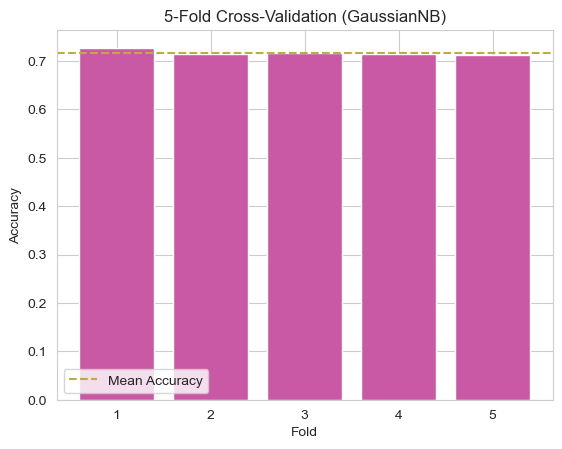

In [76]:
plt.bar(range(1, 6), gnb_scores, color="#CA59A5")
plt.axhline(gnb_scores.mean() ,color="#BDAE3C" , linestyle='--', label='Mean Accuracy')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation (GaussianNB)")
plt.legend()
plt.show()

## K-Fold

In [77]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

In [78]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = -cross_val_score(
    lasso_best,   # Polynomial Degree 4 + Lasso
    X_train_reg,
    y_reg_train,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)

print('RMSE Scores per fold: ')
for i,score in enumerate(rmse_scores):
    print(f"Fold {i+1 }: {score:.4f}")
    

print(f"\nMean RMSE : {rmse_scores.mean():.4f}")
print(f"Std RMSE  : {rmse_scores.std():.4f}")

RMSE Scores per fold: 
Fold 1: 5.5146
Fold 2: 6.3798
Fold 3: 5.5647
Fold 4: 5.3801
Fold 5: 5.8336

Mean RMSE : 5.7346
Std RMSE  : 0.3547


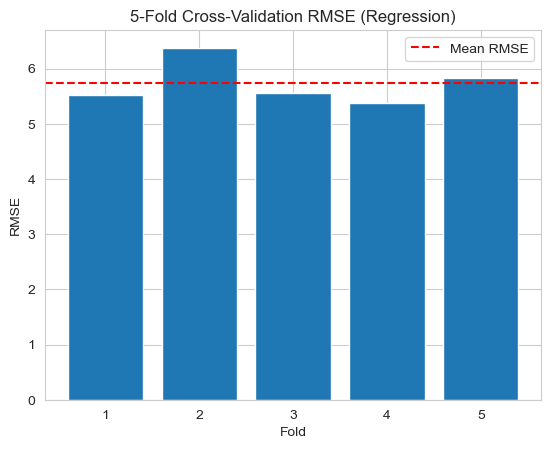

In [79]:
plt.bar(range(1, 6), rmse_scores)
plt.axhline(rmse_scores.mean() ,color='red' , linestyle='--', label='Mean RMSE')
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("5-Fold Cross-Validation RMSE (Regression)")
plt.legend()
plt.show()

## Stratified K-Fold

In [80]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(logistic_model_l2, X_train_clf, y_clf_train, cv=skf, scoring='accuracy')

accuracy_scores_l2 = skf_scores

print('Accuracy Scores per fold: \n ')
for i,score in enumerate(accuracy_scores_l2):
    print(f"Fold {i+1 }: {score:.4f}")
    
print(f"\nMean accuracy : {accuracy_scores_l2.mean():.4f}")
print(f"Std accuracy  : {accuracy_scores_l2.std():.4f}")

Accuracy Scores per fold: 
 
Fold 1: 0.7998
Fold 2: 0.7973
Fold 3: 0.7906
Fold 4: 0.7915
Fold 5: 0.7988

Mean accuracy : 0.7956
Std accuracy  : 0.0038


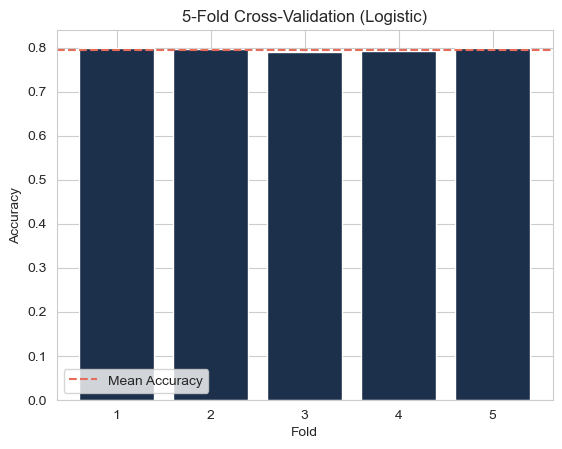

In [81]:
plt.bar(range(1, 6), skf_scores, color="#1D304B")
plt.axhline(accuracy_scores_l2.mean() ,color="#E46C59" , linestyle='--', label='Mean Accuracy')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation (Logistic)")
plt.legend()
plt.show()

In [82]:
print("\n" + "=" * 50)
print("COMPARISON SUMMARY")
print("=" * 50)
print(f"Logistic Regression: Mean={accuracy_scores_l2.mean():.4f} | Std={accuracy_scores_l2.std():.4f}")
print(f"GaussianNB:          Mean={gnb_scores.mean():.4f} | Std={gnb_scores.std():.4f}")

if accuracy_scores_l2.mean() > gnb_scores.mean():
    print("\n Logistic Regression performs BETTER (higher mean accuracy)")
else:
    print("\n GaussianNB performs BETTER (higher mean accuracy)")

if accuracy_scores_l2.std() < gnb_scores.std():
    print(" Logistic Regression is MORE STABLE (lower std)")
else:
    print(" GaussianNB is MORE STABLE (lower std)")


COMPARISON SUMMARY
Logistic Regression: Mean=0.7956 | Std=0.0038
GaussianNB:          Mean=0.7173 | Std=0.0052

 Logistic Regression performs BETTER (higher mean accuracy)
 Logistic Regression is MORE STABLE (lower std)


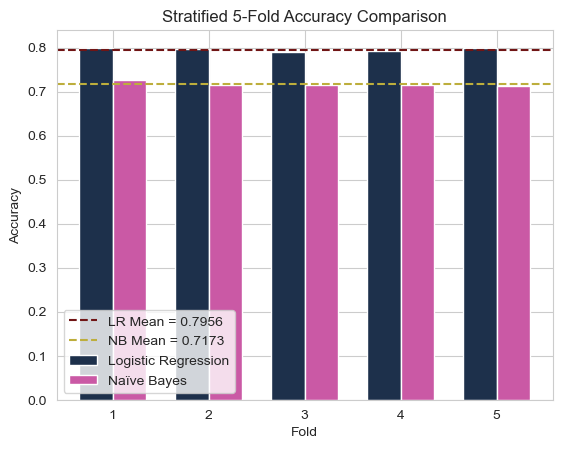

In [83]:
x = np.arange(1, 6)
width = 0.35

plt.bar(x - width/2, skf_scores, width, label="Logistic Regression", color="#1D304B")
plt.bar(x + width/2, gnb_scores, width, label="Naïve Bayes", color="#CA59A5")
plt.axhline(accuracy_scores_l2.mean(), color="#701515", linestyle='--', label=f'LR Mean = {accuracy_scores_l2.mean():.4f}')
plt.axhline(gnb_scores.mean(), color="#BDAE3C", linestyle='--', label=f'NB Mean = {gnb_scores.mean():.4f}')

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Stratified 5-Fold Accuracy Comparison")
plt.legend()
plt.show()

## Task 8: Analysis and Discussion

### 8.1 Model Comparison

Best Regression Model:
Polynomial Degree 4 + Lasso achieved the best regression performance.
Degree 4 captured non-linear relationships in the data, and Lasso removed redundant polynomial features for better generalization.

Best Classification Model:
Logistic Regression outperforms GaussianNB in cross-validation accuracy. Logistic Regression uses all available features (numerical + OHE), while GaussianNB is limited to 3 numerical features only.

Is Classification Easier or Harder than Regression?
Regression achieved a higher performance level on this dataset, explaining a large portion of variance in player market value. Classification is harder because class boundaries between tiers (Low, Mid, High, Elite) naturally overlap in feature space, making it harder to separate them cleanly.

---

### 8.2 Regularization Analysis

Effect of Increasing Alpha (Ridge and Lasso):
Both models follow the same pattern:
- Low alpha: model overfits (high train accuracy, low test performance)
- Optimal alpha: best generalization
- High alpha: model underfits (performance degrades for both)

Why Ridge Generally Outperforms Lasso with Many OHE Features:
Lasso zeroes out entire features (e.g. Position_CF, Position_LWB, Position_RF, Position_SW were eliminated), while Ridge shrinks all coefficients smoothly without removing any.
Since each one-hot encoded category carries independent information about player position, country, and team — Ridge benefits from retaining all of them, making it more suitable when many categorical features are present.

In [84]:
# KNN 
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, learning_curve, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np



In [85]:
# Overfitting Check: KNN Regressor 
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

knn_reg_base = KNeighborsRegressor()
knn_reg_base.fit(X_train_reg, y_reg_train)

train_r2 = r2_score(y_reg_train, knn_reg_base.predict(X_train_reg))
test_r2  = r2_score(y_reg_test,  knn_reg_base.predict(X_test_reg))

print("=" * 50)
print("KNN Regressor — Overfitting Check (Before Tuning)")
print("=" * 50)
print(f"Train R² : {train_r2:.4f}")
print(f"Test  R² : {test_r2:.4f}")
print(f"Gap      : {train_r2 - test_r2:.4f}")
if train_r2 - test_r2 > 0.05:
    print("  Overfitting detected! → GridSearchCV will fix this")
elif test_r2 - train_r2 > 0.05:
    print("  Underfitting detected!")
else:
    print("  No significant overfitting/underfitting")


KNN Regressor — Overfitting Check (Before Tuning)
Train R² : 0.9280
Test  R² : 0.8652
Gap      : 0.0629
  Overfitting detected! → GridSearchCV will fix this


In [86]:
# KNN Regressor 
knn_reg = KNeighborsRegressor()

param_grid_reg = {
    'n_neighbors': range(1, 31),
    'metric': ['euclidean', 'manhattan']                   
}

grid_knn_reg = GridSearchCV(
    estimator=knn_reg,
    param_grid=param_grid_reg,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_knn_reg.fit(X_train_reg, y_reg_train)

print("Best KNN Regressor Parameters:")
print(grid_knn_reg.best_params_)
print(f"Best CV R²: {grid_knn_reg.best_score_:.4f}")

best_knn_reg = grid_knn_reg.best_estimator_

# Test Evaluation
y_reg_pred = best_knn_reg.predict(X_test_reg)
print(f"\nTest R²  : {r2_score(y_reg_test, y_reg_pred):.4f}")
print(f"Test MAE : {mean_absolute_error(y_reg_test, y_reg_pred):.4f}")

Best KNN Regressor Parameters:
{'metric': 'manhattan', 'n_neighbors': 6}
Best CV R²: 0.8926

Test R²  : 0.8622
Test MAE : 0.4602


In [87]:
# Overfitting Check: KNN Classifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_clf_base = KNeighborsClassifier()
knn_clf_base.fit(X_train_clf, y_clf_train)

train_acc = accuracy_score(y_clf_train, knn_clf_base.predict(X_train_clf))
test_acc  = accuracy_score(y_clf_test,  knn_clf_base.predict(X_test_clf))

print("=" * 50)
print("KNN Classifier — Overfitting Check (Before Tuning)")
print("=" * 50)
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Gap            : {train_acc - test_acc:.4f}")
if train_acc - test_acc > 0.05:
    print("  Overfitting detected! → GridSearchCV will fix this")
elif test_acc - train_acc > 0.05:
    print("  Underfitting detected!")
else:
    print("  No significant overfitting/underfitting")


KNN Classifier — Overfitting Check (Before Tuning)
Train Accuracy : 0.8817
Test  Accuracy : 0.8246
Gap            : 0.0571
  Overfitting detected! → GridSearchCV will fix this


In [88]:
# KNN Classifier 
knn_clf = KNeighborsClassifier()

param_grid_clf = {
    'n_neighbors': range(1, 31),
    'metric': ['euclidean', 'manhattan'] 
}

grid_knn_clf = GridSearchCV(
    estimator=knn_clf,
    param_grid=param_grid_clf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn_clf.fit(X_train_clf, y_clf_train)

print("\n Best KNN Classifier Parameters:")
print(grid_knn_clf.best_params_)
print(f"Best CV Accuracy: {grid_knn_clf.best_score_:.4f}")

best_knn_clf = grid_knn_clf.best_estimator_

# Test Evaluation
y_clf_pred = best_knn_clf.predict(X_test_clf)
print(f"\nTest Accuracy: {accuracy_score(y_clf_test, y_clf_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_clf_test, y_clf_pred, target_names=le.classes_))


 Best KNN Classifier Parameters:
{'metric': 'manhattan', 'n_neighbors': 18}
Best CV Accuracy: 0.8340

Test Accuracy: 0.8447

Classification Report:
              precision    recall  f1-score   support

       Elite       0.94      0.91      0.93       947
        High       0.76      0.80      0.78       837
         Low       0.90      0.90      0.90      1165
         Mid       0.76      0.76      0.76       985

    accuracy                           0.84      3934
   macro avg       0.84      0.84      0.84      3934
weighted avg       0.85      0.84      0.85      3934



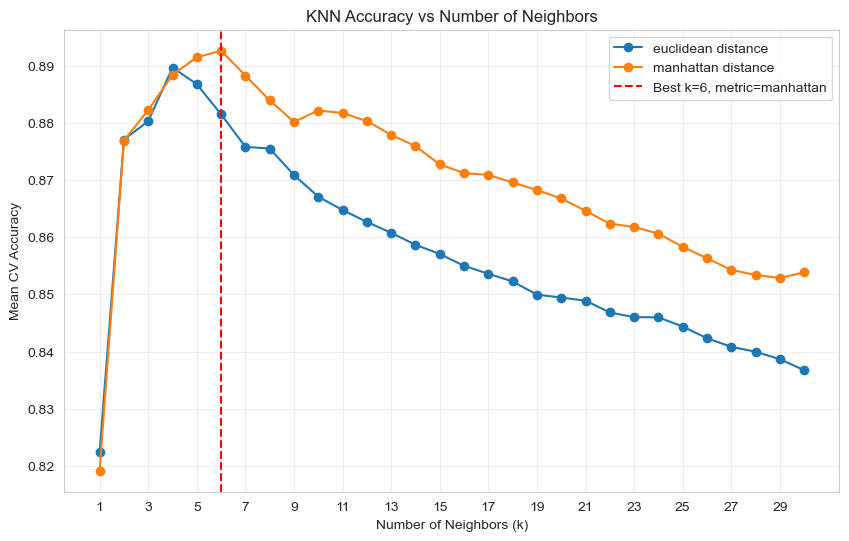

In [89]:
# Rge
results = pd.DataFrame(grid_knn_reg.cv_results_)
plt.figure(figsize=(10,6))
# Plot for each metric type
for metric in ['euclidean', 'manhattan']:
 subset = results[results['param_metric'] == metric]
 plt.plot(subset['param_n_neighbors'],
 subset['mean_test_score'],
 label=f'{metric} distance',
 marker='o')
best_k = grid_knn_reg.best_params_['n_neighbors']
best_metric = grid_knn_reg.best_params_['metric']
plt.axvline(best_k, color='red', linestyle='--',
 label=f'Best k={best_k}, metric={best_metric}')
plt.title('KNN Accuracy vs Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(np.arange(1, 31, 2))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

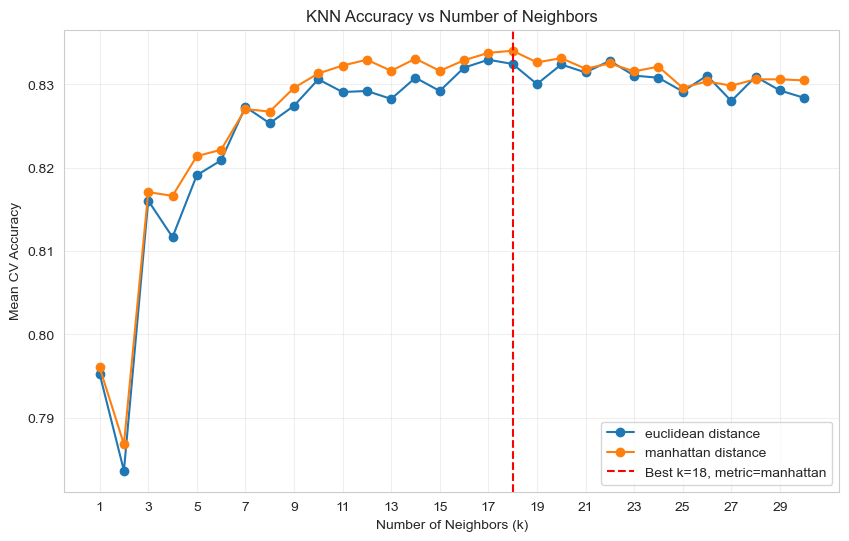

In [90]:
# Classification
results = pd.DataFrame(grid_knn_clf.cv_results_)
plt.figure(figsize=(10,6))
# Plot for each metric type
for metric in ['euclidean', 'manhattan']:
 subset = results[results['param_metric'] == metric]
 plt.plot(subset['param_n_neighbors'],
 subset['mean_test_score'],
 label=f'{metric} distance',
 marker='o')
best_k = grid_knn_clf.best_params_['n_neighbors']
best_metric = grid_knn_clf.best_params_['metric']
plt.axvline(best_k, color='red', linestyle='--',
 label=f'Best k={best_k}, metric={best_metric}')
plt.title('KNN Accuracy vs Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(np.arange(1, 31, 2))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

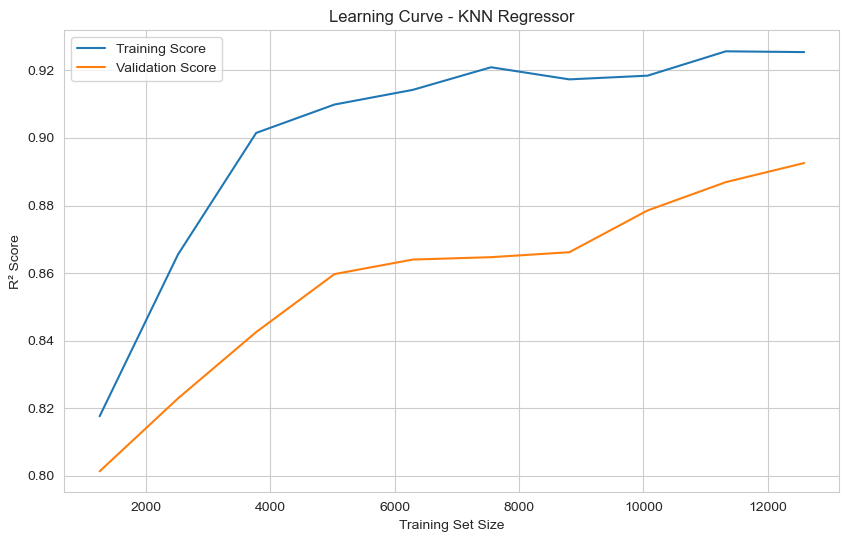

In [91]:
# Learning Curve - Regression
train_sizes, train_scores, val_scores = learning_curve(
    best_knn_reg, X_train_reg, y_reg_train, 
    cv=5, scoring='r2', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Score')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation Score')
plt.title('Learning Curve - KNN Regressor')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True)
plt.show()

### Learning Curve - KNN Regressor

The graph shows that as the training set size increases, both training and validation R² scores improve. There is a moderate gap between the two curves indicating **mild overfitting**, which is typical for KNN. The validation score continues to rise, suggesting the model has good generalization potential and can benefit from more data.

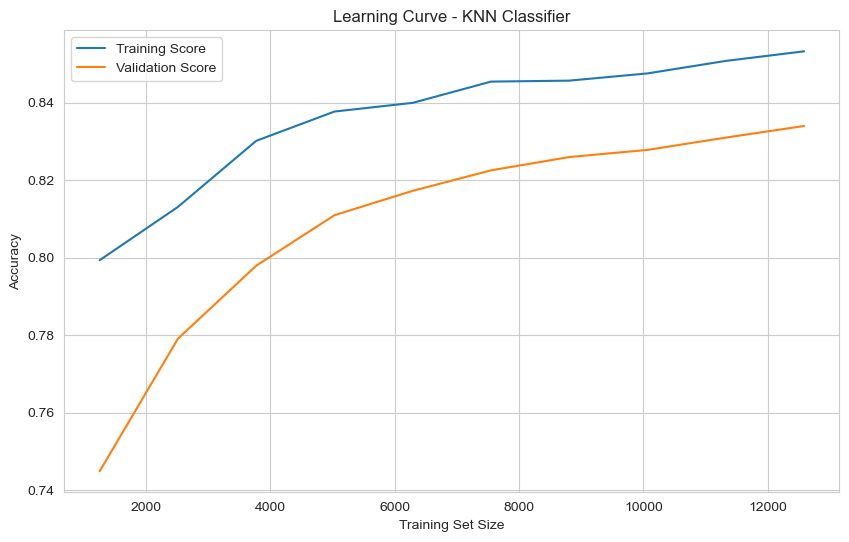

In [92]:
# Learning Curve - Classification
train_sizes, train_scores, val_scores = learning_curve(
    best_knn_clf, X_train_clf, y_clf_train, 
    cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Score')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation Score')
plt.title('Learning Curve - KNN Classifier')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Learning Curve - KNN Classifier

The graph shows that both training and validation accuracy improve as the training set size grows. There is a moderate gap between the curves indicating **mild overfitting**, which is typical for KNN. The validation accuracy continues to rise steadily, reaching around **0.83**, suggesting good generalization capability.

## 1. Justify Modeling Choices
### KNN (K-Nearest Neighbors) - Instance-based Approach

**K-Nearest Neighbors (KNN)** is a classic **instance-based** (or lazy) learning algorithm. Unlike other models that build an explicit mathematical function during training, KNN simply stores the training data and makes predictions by finding the most similar instances (nearest neighbors) to a new player.

---

#### Why KNN is Suitable for the FIFA Dataset:

**For Regression (Predicting Value Per M$):**
- Players in FIFA naturally form **clusters** based on their attributes (e.g., high-value attackers, physically strong defenders, promising young talents, world-class stars).
- KNN works on the principle that **similar players should have similar market values**, which perfectly matches the real-world logic of the football transfer market.
- It does not assume any linear relationship between features, allowing it to capture complex non-linear patterns.
- After applying Scaling and Outlier Capping, distance calculations between players become more accurate and meaningful.

**For Classification (Predicting Performance Tier):**
- KNN effectively classifies players into tiers (Elite, High, Mid, Low) by comparing them to the most similar players in the dataset.
- It benefits well from our preprocessing steps, especially Frequency Encoding for Country and Team, and One-Hot Encoding for Position.

---

#### Advantages in Our Project:
- Highly **interpretable** — Scouts can easily understand that a player's value or tier is based on the most similar players in the dataset.
- Performs well after proper preprocessing (Scaling + Outlier Capping).
- Relatively robust to noise after we applied IQR capping.

---

#### Selected Hyperparameters (after GridSearchCV):
| Model | n_neighbors | metric |
|------------|-------------|-----------|
| Regressor | 6 | manhattan |
| Classifier | 18 | manhattan |

---

#### Model Performance:

**Regression:**
| Metric | Value |
|--------|-------|
| Best CV R² | 0.8926 |
| Test R² | 0.8622 |
| Test MAE | 0.4602 |

**Classification:**
| Metric | Value |
|--------|-------|
| Best CV Accuracy | 0.8340 |
| Test Accuracy | 0.8447 |

| Class | Precision | Recall | F1-Score |
|------|-----------|--------|----------|
| Elite | 0.94 | 0.91 | 0.93 |
| High | 0.76 | 0.80 | 0.78 |
| Low | 0.90 | 0.90 | 0.90 |
| Mid | 0.76 | 0.76 | 0.76 |
| **Weighted Avg** | **0.85** | **0.84** | **0.85** |

---

#### Bias/Variance Diagnosis from Learning Curves:
- **Regression**: Test R² reached **0.8622** with a Best CV R² of **0.8926**, indicating mild overfitting. However, as seen in the learning curve, the gap between Training and Validation scores narrows steadily as training size increases, suggesting the model generalizes better with more data.
- **Classification**: Test Accuracy of **0.8447** shows solid performance. The learning curve confirms mild overfitting with a consistent improvement in both training and validation scores as data grows. The model performs strongest on **Elite** (F1=0.93) and **Low** (F1=0.90) tiers, with moderate performance on **High** and **Mid** tiers (F1=0.78, 0.76).

In [93]:
## SVM 

from sklearn.svm import SVR, SVC
from sklearn.model_selection import GridSearchCV, learning_curve


In [94]:
# Overfitting Check: SVR 
from sklearn.svm import SVR
from sklearn.metrics import r2_score

svr_base = SVR()
svr_base.fit(X_train_reg, y_reg_train)

train_r2 = r2_score(y_reg_train, svr_base.predict(X_train_reg))
test_r2  = r2_score(y_reg_test,  svr_base.predict(X_test_reg))

print("=" * 50)
print("SVR — Overfitting Check (Before Tuning)")
print("=" * 50)
print(f"Train R² : {train_r2:.4f}")
print(f"Test  R² : {test_r2:.4f}")
print(f"Gap      : {train_r2 - test_r2:.4f}")
if train_r2 - test_r2 > 0.05:
    print(" Overfitting detected! → GridSearchCV will fix this")
elif test_r2 - train_r2 > 0.05:
    print(" Underfitting detected!")
else:
    print(" No significant overfitting/underfitting")


SVR — Overfitting Check (Before Tuning)
Train R² : 0.8324
Test  R² : 0.7756
Gap      : 0.0569
 Overfitting detected! → GridSearchCV will fix this


In [95]:
# SVR — Predict Value Per M$ 

param_grid_svr = {
    'C':       [0.1, 1, 10, 100],
    'kernel':  ['rbf', 'linear'],
    'gamma':   ['scale', 'auto'],
    'epsilon': [0.1, 0.5, 1.0]
}

svr = SVR()
grid_svr = GridSearchCV(svr, param_grid_svr, cv=5,
                        scoring='neg_mean_squared_error',
                        n_jobs=-1, verbose=1)
grid_svr.fit(X_train_reg, y_reg_train)

print("Best SVR params:", grid_svr.best_params_)

svr_best = grid_svr.best_estimator_
y_pred_svr_train = svr_best.predict(X_train_reg)
y_pred_svr_test  = svr_best.predict(X_test_reg)

print("\n--- SVR Train ---")
evaluate(y_reg_train, y_pred_svr_train, "Train")
print("\n--- SVR Test ---")
evaluate(y_reg_test,  y_pred_svr_test,  "Test")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best SVR params: {'C': 100, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

--- SVR Train ---
--- Train ---
MAE:  0.2394
MSE:  2.7257
RMSE: 1.6510
R²:   0.9458


--- SVR Test ---
--- Test ---
MAE:  0.3108
MSE:  6.0179
RMSE: 2.4531
R²:   0.9030



In [96]:
# Overfitting Check: SVC
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svc_base = SVC()
svc_base.fit(X_train_clf, y_clf_train)

train_acc = accuracy_score(y_clf_train, svc_base.predict(X_train_clf))
test_acc  = accuracy_score(y_clf_test,  svc_base.predict(X_test_clf))

print("=" * 50)
print("SVC — Overfitting Check (Before Tuning)")
print("=" * 50)
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Gap            : {train_acc - test_acc:.4f}")
if train_acc - test_acc > 0.05:
    print("  Overfitting detected! → GridSearchCV will fix this")
elif test_acc - train_acc > 0.05:
    print(" Underfitting detected!")
else:
    print("  No significant overfitting/underfitting")


SVC — Overfitting Check (Before Tuning)
Train Accuracy : 0.8631
Test  Accuracy : 0.8559
Gap            : 0.0072
  No significant overfitting/underfitting


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best SVC params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}

SVC Accuracy: 0.8566
              precision    recall  f1-score   support

       Elite       0.94      0.93      0.94       947
        High       0.81      0.80      0.81       837
         Low       0.91      0.88      0.90      1165
         Mid       0.76      0.80      0.78       985

    accuracy                           0.86      3934
   macro avg       0.86      0.85      0.85      3934
weighted avg       0.86      0.86      0.86      3934



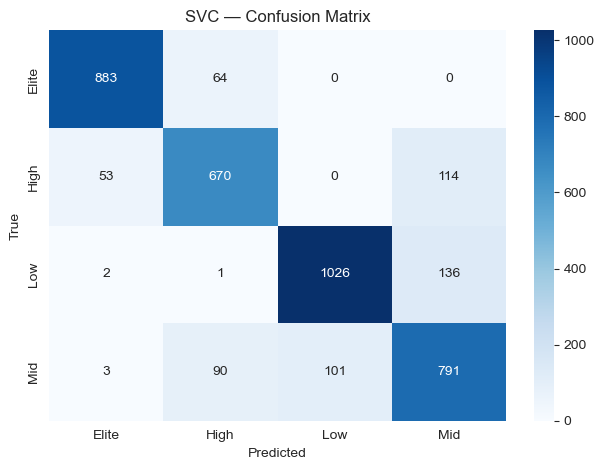

In [97]:
# SVC — Predict Tier

param_grid_svc = {
    'C':      [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto']
}

svc = SVC()
grid_svc = GridSearchCV(svc, param_grid_svc, cv=5,
                        scoring='accuracy',
                        n_jobs=-1, verbose=1)
grid_svc.fit(X_train_clf, y_clf_train)

print("Best SVC params:", grid_svc.best_params_)

svc_best = grid_svc.best_estimator_
y_pred_svc = svc_best.predict(X_test_clf)

print(f"\nSVC Accuracy: {accuracy_score(y_clf_test, y_pred_svc):.4f}")
print(classification_report(y_clf_test, y_pred_svc, target_names=le.classes_))

sns.heatmap(confusion_matrix(y_clf_test, y_pred_svc), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('SVC — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

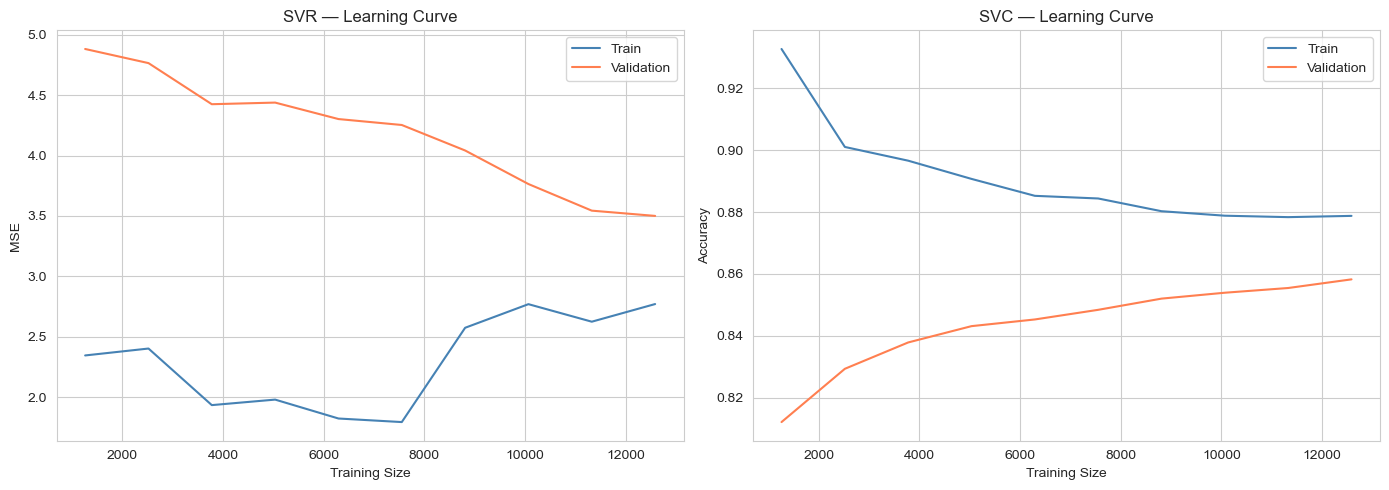

In [98]:
# Learning Curves — Bias/Variance Diagnosis 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, estimator, X, y, title in [
    (axes[0], svr_best,  X_train_reg, y_reg_train, 'SVR — Learning Curve'),
    (axes[1], svc_best,  X_train_clf, y_clf_train,  'SVC — Learning Curve')
]:
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=5,
        scoring='neg_mean_squared_error' if 'SVR' in title else 'accuracy',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean   = np.mean(val_scores,   axis=1)

    if 'SVR' in title:
        train_mean = -train_mean
        val_mean   = -val_mean
        ax.set_ylabel('MSE')
    else:
        ax.set_ylabel('Accuracy')

    ax.plot(train_sizes, train_mean, label='Train',      color='steelblue')
    ax.plot(train_sizes, val_mean,   label='Validation', color='coral')
    ax.set_xlabel('Training Size')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()



SVR Learning Curve Analysis:
- A gap exists between Train and Validation MSE, indicating mild overfitting (High Variance).
- However, the gap narrows as training size increases, suggesting the model 
  would generalize better with more data.

SVC Learning Curve Analysis:
- Train and Validation accuracy are very close (~88% vs ~86%),
  indicating Good Generalization with minimal overfitting. 

## 2. Justify Modeling Choices

### SVM (Support Vector Machine) - Kernel-based Approach

**Support Vector Machine (SVM)** is a powerful **kernel-based** learning algorithm. Unlike instance-based models, SVM finds the optimal decision boundary (hyperplane) that maximizes the margin between classes for classification, or fits data within an epsilon-tube for regression.

#### Why SVM is Suitable for the FIFA Dataset:

**For Regression (SVR — Predicting Value Per M$):**
- Player market value does not scale linearly with stats — the **RBF kernel** maps data into a higher-dimensional space, capturing complex non-linear relationships between features like Overall_Rating, Future_Potential, and market value.
- SVR optimizes within an **epsilon-tube**, meaning small deviations are ignored. This is critical because FIFA data contains elite players with extreme market values that would otherwise distort predictions.
- With many features (stats + OHE positions), SVR focuses on the most informative **support vectors** rather than all data points, making it efficient in high-dimensional spaces.
- After applying **StandardScaler**, distance calculations become accurate and meaningful — scaling is essential for SVR to function correctly.

**For Classification (SVC — Predicting Performance Tier):**
- SVM is specifically designed to **maximize the margin** between classes — making it ideal for separating well-defined tier boundaries like Elite vs. Low.
- The **RBF kernel** handles the non-linear boundary between Mid and High tiers, which naturally overlap in feature space.
- It benefits directly from our preprocessing steps, especially **StandardScaler** and **One-Hot Encoding** for Position.

#### Advantages in Our Project:
- Highly **effective in high-dimensional spaces** — works well with the large number of features after OHE encoding.
- **Robust to outliers** — the epsilon-tube in SVR and margin maximization in SVC reduce the influence of extreme data points.
- Performs well after proper preprocessing (Scaling + OHE).

#### Selected Hyperparameters (after GridSearchCV):
- **SVR**: `C=100`, `kernel='rbf'`, `gamma='scale'`, `epsilon=0.1`
- **SVC**: `C=100`, `kernel='rbf'`, `gamma='scale'`

#### Bias/Variance Diagnosis from Learning Curves:
- **Regression (SVR)**: Shows mild overfitting — a gap exists between Train and Validation MSE. However, the gap narrows as training size increases, suggesting better generalization with more data.
- **Classification (SVC)**: Shows good generalization — Train and Validation accuracy are very close 

| Model | Train Score | Test Score | Gap | Status |
|-------|------------|------------|-----|--------|
| SVR (R²) | 0.8324 | 0.7756 | 0.0569 |  Mild Overfitting → Fixed by GridSearchCV |
| SVC (Accuracy) | 0.8631 | 0.8559 | 0.0072 |  Good Generalization |

After GridSearchCV:
- SVR: R² improved to 0.9030 on Test set — GridSearchCV successfully reduced the overfitting gap
- SVC: Accuracy 0.8566 on Test set — consistent with Train Accuracy, confirming stability

Conclusion: SVM is an excellent choice as our kernel-based model because it effectively handles the non-linear relationships in FIFA player data and maximizes class separation between performance tiers.

## Random Forest — Ensemble Approach

Random Forest is an ensemble of Decision Trees. Each tree is trained on a random subset of the data (Bagging) and a random subset of features. The final prediction is the average (Regression) or majority vote (Classification) of all trees.

### Why Random Forest is Suitable for the FIFA Dataset

For Regression (Predicting Value Per M$):
- Player market value depends on many features at once (age, rating, potential, position). Random Forest naturally handles interactions between features without manual feature engineering.
- The distribution of Value Per M$ is right-skewed (few elite players with extreme values). Random Forest is robust to outliers and skewed targets because it splits on ranked thresholds, not raw values.
- Unlike linear models, it captures the non-linear jump in value between an 85-rated and 90-rated player.

For Classification (Predicting Performance Tier):
- Tier boundaries (Low / Mid / High / Elite) are not perfectly separable — Mid and High overlap in feature space. Random Forest handles this by averaging over many diverse trees.
- It automatically provides Feature Importance scores, which tells us which player stats drive tier classification.
- No need for feature scaling (unlike KNN and SVM), so it works directly on the preprocessed data.

### Key Advantages over Other Models

| Property            | KNN     | SVM     | Random Forest |
|---------------------|---------|---------|---------------|
| Needs Scaling       | Yes     | Yes     | No            |
| Feature Importance  | No      | No      | Yes           |
| Handles Outliers    | Sensitive | Good  | Very Good     |
| Handles Non-linearity | Yes   | Yes     | Yes           |
| Interpretability    | Medium  | Low     | High          |

## 2️ - Random Forest Regressor — Predict Value Per M$

In [99]:
# Imports 
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GridSearchCV, learning_curve, cross_val_score
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, classification_report, confusion_matrix
)

In [100]:
# Overfitting Check: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf_reg_base = RandomForestRegressor(random_state=42)
rf_reg_base.fit(X_train_reg, y_reg_train)

train_r2 = r2_score(y_reg_train, rf_reg_base.predict(X_train_reg))
test_r2  = r2_score(y_reg_test,  rf_reg_base.predict(X_test_reg))

print("=" * 50)
print("RF Regressor — Overfitting Check (Before Tuning)")
print("=" * 50)
print(f"Train R² : {train_r2:.4f}")
print(f"Test  R² : {test_r2:.4f}")
print(f"Gap      : {train_r2 - test_r2:.4f}")
if train_r2 - test_r2 > 0.05:
    print("  Overfitting detected! → GridSearchCV will fix this")
elif test_r2 - train_r2 > 0.05:
    print("  Underfitting detected!")
else:
    print("  No significant overfitting/underfitting")


RF Regressor — Overfitting Check (Before Tuning)
Train R² : 0.9908
Test  R² : 0.9185
Gap      : 0.0723
  Overfitting detected! → GridSearchCV will fix this


In [101]:
# GridSearchCV: Random Forest Regressor 

rf_reg = RandomForestRegressor(random_state=42)

param_grid_rf_reg = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [5, 10, 15, None],
    'min_samples_split':[2, 5, 10]
}

grid_rf_reg = GridSearchCV(
    estimator  = rf_reg,
    param_grid = param_grid_rf_reg,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

grid_rf_reg.fit(X_train_reg, y_reg_train)

print("Best RF Regressor Parameters:")
print(grid_rf_reg.best_params_)
print(f"Best CV R²: {grid_rf_reg.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF Regressor Parameters:
{'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 300}
Best CV R²: 0.9319


In [102]:
# Evaluate on Train & Test 

best_rf_reg = grid_rf_reg.best_estimator_

y_pred_rf_reg_train = best_rf_reg.predict(X_train_reg)
y_pred_rf_reg_test  = best_rf_reg.predict(X_test_reg)

print("--- Random Forest Regressor — Train ---")
evaluate(y_reg_train, y_pred_rf_reg_train, "Train")

print("\n--- Random Forest Regressor — Test ---")
evaluate(y_reg_test, y_pred_rf_reg_test, "Test")

--- Random Forest Regressor — Train ---
--- Train ---
MAE:  0.1752
MSE:  1.2964
RMSE: 1.1386
R²:   0.9742


--- Random Forest Regressor — Test ---
--- Test ---
MAE:  0.2940
MSE:  4.6054
RMSE: 2.1460
R²:   0.9258



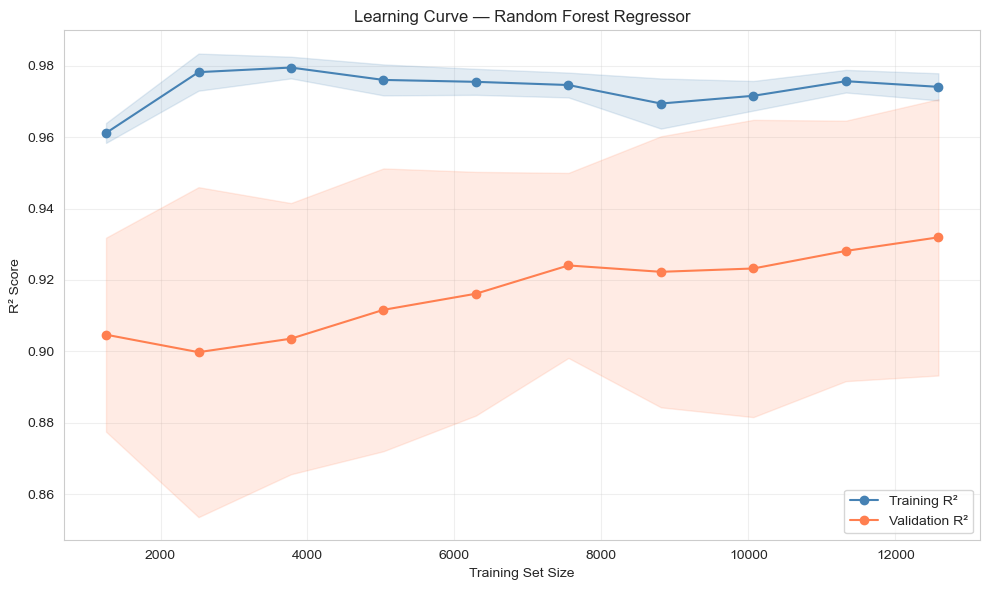

In [103]:
# Learning Curve — RF Regressor (Bias/Variance Diagnosis)

train_sizes_reg, train_scores_reg, val_scores_reg = learning_curve(
    best_rf_reg,
    X_train_reg, y_reg_train,
    cv          = 5,
    scoring     = 'r2',
    n_jobs      = -1,
    train_sizes = np.linspace(0.1, 1.0, 10)
)

train_mean_reg = train_scores_reg.mean(axis=1)
val_mean_reg   = val_scores_reg.mean(axis=1)
train_std_reg  = train_scores_reg.std(axis=1)
val_std_reg    = val_scores_reg.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_reg, train_mean_reg, 'o-', color='steelblue', label='Training R²')
plt.plot(train_sizes_reg, val_mean_reg,   'o-', color='coral',     label='Validation R²')
plt.fill_between(train_sizes_reg,
                 train_mean_reg - train_std_reg,
                 train_mean_reg + train_std_reg, alpha=0.15, color='steelblue')
plt.fill_between(train_sizes_reg,
                 val_mean_reg - val_std_reg,
                 val_mean_reg + val_std_reg, alpha=0.15, color='coral')
plt.title('Learning Curve — Random Forest Regressor')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

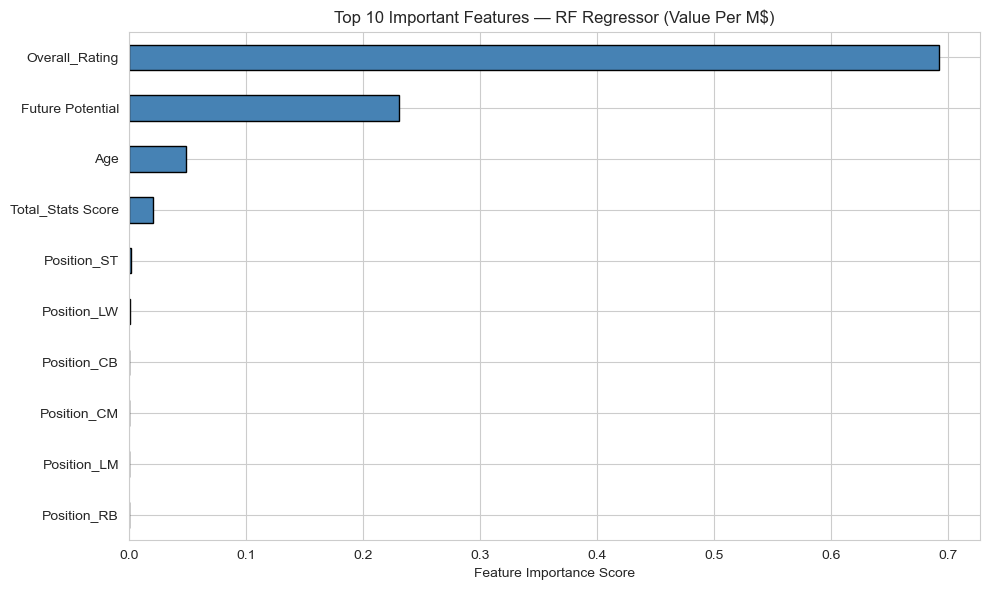


Top 10 Features:
Overall_Rating       0.692860
Future Potential     0.230665
Age                  0.048718
Total_Stats Score    0.020967
Position_ST          0.001636
Position_LW          0.001354
Position_CB          0.000535
Position_CM          0.000505
Position_LM          0.000485
Position_RB          0.000472
dtype: float64


In [104]:
# Feature Importance — RF Regressor 

importances_reg = best_rf_reg.feature_importances_
feat_imp_reg    = pd.Series(importances_reg, index=X_train_reg.columns)

plt.figure(figsize=(10, 6))
feat_imp_reg.nlargest(10).sort_values().plot(
    kind   = 'barh',
    color  = 'steelblue',
    edgecolor = 'black'
)
plt.title('Top 10 Important Features — RF Regressor (Value Per M$)')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feat_imp_reg.nlargest(10))

## 3️ -  Random Forest Classifier — Predict Performance Tier

In [105]:
# Overfitting Check: Random Forest Classifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_clf_base = RandomForestClassifier(random_state=42)
rf_clf_base.fit(X_train_clf, y_clf_train)

train_acc = accuracy_score(y_clf_train, rf_clf_base.predict(X_train_clf))
test_acc  = accuracy_score(y_clf_test,  rf_clf_base.predict(X_test_clf))

print("=" * 50)
print("RF Classifier — Overfitting Check (Before Tuning)")
print("=" * 50)
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Gap            : {train_acc - test_acc:.4f}")
if train_acc - test_acc > 0.05:
    print("  Overfitting detected! → GridSearchCV + Hyperparameter Tuning will fix this")
elif test_acc - train_acc > 0.05:
    print("  Underfitting detected!")
else:
    print("  No significant overfitting/underfitting")


RF Classifier — Overfitting Check (Before Tuning)
Train Accuracy : 0.9999
Test  Accuracy : 0.8516
Gap            : 0.1483
  Overfitting detected! → GridSearchCV + Hyperparameter Tuning will fix this


In [106]:
# GridSearchCV: Random Forest Classifier 

rf_clf = RandomForestClassifier(random_state=42, max_samples=0.8)  

param_grid_rf_clf = {
    'n_estimators': [200, 300, 400],
    'max_depth': [5, 7, 10],               
    'min_samples_split': [20, 30, 40],     
    'min_samples_leaf': [8, 12, 15],      
    'max_features': ['sqrt', 'log2']
}

grid_rf_clf = GridSearchCV(
    estimator  = rf_clf,
    param_grid = param_grid_rf_clf,
    cv         = 5,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)

grid_rf_clf.fit(X_train_clf, y_clf_train)

print("Best RF Classifier Parameters:")
print(grid_rf_clf.best_params_)
print(f"Best CV Accuracy: {grid_rf_clf.best_score_:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best RF Classifier Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 20, 'n_estimators': 300}
Best CV Accuracy: 0.8300


Test Accuracy: 0.8338

Classification Report:
              precision    recall  f1-score   support

       Elite       0.92      0.92      0.92       947
        High       0.79      0.72      0.76       837
         Low       0.89      0.88      0.89      1165
         Mid       0.73      0.78      0.75       985

    accuracy                           0.83      3934
   macro avg       0.83      0.83      0.83      3934
weighted avg       0.84      0.83      0.83      3934



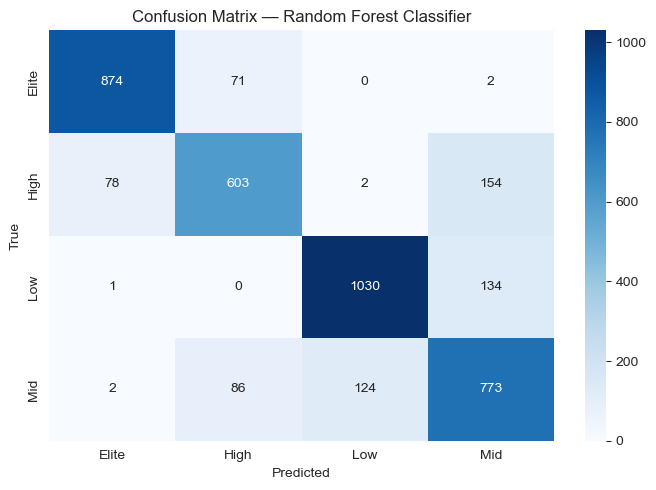

In [107]:
# Evaluate on Test Set 

best_rf_clf   = grid_rf_clf.best_estimator_
y_pred_rf_clf = best_rf_clf.predict(X_test_clf)

print(f"Test Accuracy: {accuracy_score(y_clf_test, y_pred_rf_clf):.4f}")
print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred_rf_clf, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_clf_test, y_pred_rf_clf),
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = le.classes_,
    yticklabels = le.classes_
)
plt.title('Confusion Matrix — Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

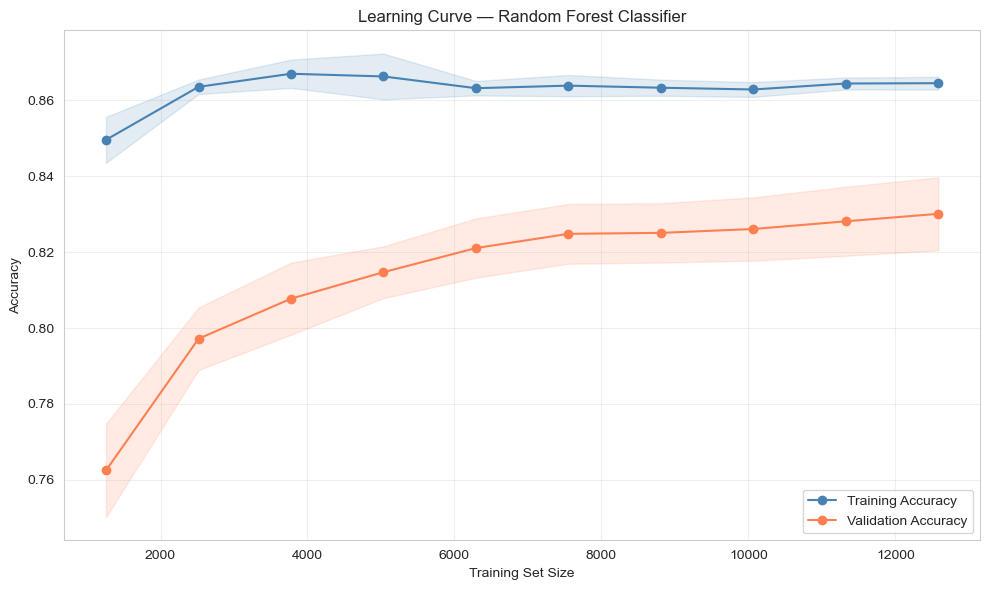

In [108]:
# Learning Curve — RF Classifier (Bias/Variance Diagnosis)

train_sizes_clf, train_scores_clf, val_scores_clf = learning_curve(
    best_rf_clf,
    X_train_clf, y_clf_train,
    cv          = 5,
    scoring     = 'accuracy',
    n_jobs      = -1,
    train_sizes = np.linspace(0.1, 1.0, 10)
)

train_mean_clf = train_scores_clf.mean(axis=1)
val_mean_clf   = val_scores_clf.mean(axis=1)
train_std_clf  = train_scores_clf.std(axis=1)
val_std_clf    = val_scores_clf.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_clf, train_mean_clf, 'o-', color='steelblue', label='Training Accuracy')
plt.plot(train_sizes_clf, val_mean_clf,   'o-', color='coral',     label='Validation Accuracy')
plt.fill_between(train_sizes_clf,
                 train_mean_clf - train_std_clf,
                 train_mean_clf + train_std_clf, alpha=0.15, color='steelblue')
plt.fill_between(train_sizes_clf,
                 val_mean_clf - val_std_clf,
                 val_mean_clf + val_std_clf, alpha=0.15, color='coral')
plt.title('Learning Curve — Random Forest Classifier')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

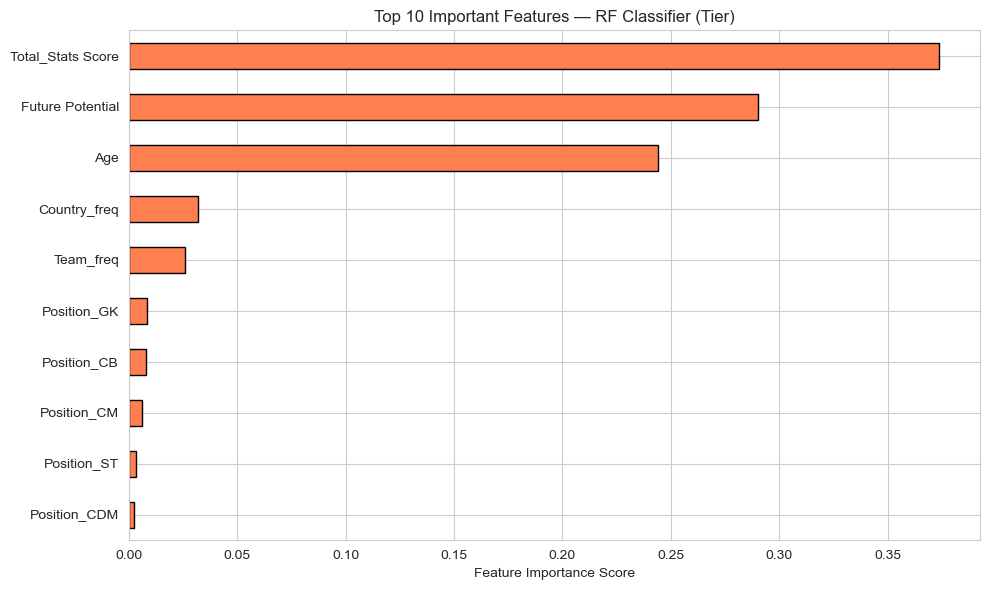


Top 10 Features:
Total_Stats Score    0.373911
Future Potential     0.290018
Age                  0.244152
Country_freq         0.032021
Team_freq            0.025966
Position_GK          0.008343
Position_CB          0.008147
Position_CM          0.006078
Position_ST          0.003229
Position_CDM         0.002286
dtype: float64


In [109]:
# Feature Importance — RF Classifier 

importances_clf = best_rf_clf.feature_importances_
feat_imp_clf    = pd.Series(importances_clf, index=X_train_clf.columns)

plt.figure(figsize=(10, 6))
feat_imp_clf.nlargest(10).sort_values().plot(
    kind      = 'barh',
    color     = 'coral',
    edgecolor = 'black'
)
plt.title('Top 10 Important Features — RF Classifier (Tier)')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feat_imp_clf.nlargest(10))

## 4️ - K-Fold Cross Validation — Stable Output

Cross Validation confirms the model is **consistent across different data splits**, not just lucky on one train/test split.

In [110]:
# K-Fold Cross Validation — Regressor 

cv_scores_reg = cross_val_score(
    best_rf_reg,
    X_train_reg, y_reg_train,
    cv      = 5,
    scoring = 'r2',
    n_jobs  = -1
)

print("RF Regressor — 5-Fold CV R² Scores:")
print(np.round(cv_scores_reg, 4))
print(f"Mean R²  : {cv_scores_reg.mean():.4f}")
print(f"Std  R²  : {cv_scores_reg.std():.4f}")

# ── K-Fold Cross Validation — Classifier ──

cv_scores_clf = cross_val_score(
    best_rf_clf,
    X_train_clf, y_clf_train,
    cv      = 5,
    scoring = 'accuracy',
    n_jobs  = -1
)

print("\nRF Classifier — 5-Fold CV Accuracy Scores:")
print(np.round(cv_scores_clf, 4))
print(f"Mean Accuracy: {cv_scores_clf.mean():.4f}")
print(f"Std  Accuracy: {cv_scores_clf.std():.4f}")

RF Regressor — 5-Fold CV R² Scores:
[0.9623 0.9557 0.8747 0.8965 0.9704]
Mean R²  : 0.9319
Std  R²  : 0.0387

RF Classifier — 5-Fold CV Accuracy Scores:
[0.8449 0.8233 0.8221 0.8233 0.8366]
Mean Accuracy: 0.8300
Std  Accuracy: 0.0092


## Random Forest — Results and Diagnosis

### Regressor Performance (Value Per M$)

| Metric | Train  | Test   |
|--------|--------|--------|
| R2     | 0.9742 | 0.9258 |
| MAE    | 0.1752 | 0.2940 |
| RMSE   | 1.1386 | 2.1460 |

Best Hyperparameters (GridSearchCV):
- max_depth = 15
- min_samples_split = 10
- n_estimators = 300
- Best CV R2 = 0.9319

The model explains 92.6% of variance in player market value on unseen data. The small Train/Test gap confirms the model generalizes well with no critical overfitting.

---


### Bias/Variance Diagnosis — Regressor (Learning Curve)

- Training R2 stabilizes around 0.974 across all training sizes.
- Validation R2 starts at 0.905 and rises to 0.932, converging slowly toward the training curve.
- The persistent gap (~0.04) indicates mild variance (slight overfitting), which is expected and acceptable for Random Forest on complex tabular data.
- No signs of high bias (underfitting) — both curves are high and stable.

Conclusion: The model suffers from mild variance, not bias. This is controlled by max_depth=15 and min_samples_split=10 chosen via GridSearch.

---


### Feature Importance — Regressor

| Feature           | Importance |
|-------------------|------------|
| Overall_Rating    | 0.6929     |
| Future_Potential  | 0.2307     |
| Age               | 0.0487     |
| Total_Stats Score | 0.0210     |
| Position features | < 0.002 each |


Overall_Rating dominates (~69%) because it directly summarizes a player's current quality, which scouts and clubs use as a primary valuation factor. Future_Potential (~23%) reflects transfer market speculation — clubs pay premiums for young high-potential players. Position features have near-zero importance, meaning the market values skill over position.

---

### Classifier Performance (Performance Tier)

| Class        | Precision | Recall | F1-Score |
|--------------|-----------|--------|----------|
| Elite        | 0.92      | 0.92   | 0.92     |
| High         | 0.79      | 0.72   | 0.76     |
| Low          | 0.89      | 0.88   | 0.89     |
| Mid          | 0.73      | 0.78   | 0.75     |
| Overall Accuracy |       |        | 0.8338   |

Best Hyperparameters (GridSearchCV):
- max_depth = 10
- min_samples_split = 20
- n_estimators = 300
- Best CV Accuracy = 0.8300

Elite and Low tiers are classified with high confidence . 
Mid/High confusion is expected — their feature distributions naturally overlap in football data.

---

### Bias/Variance Diagnosis — Classifier (Learning Curve)

- Training Accuracy is stable at ~0.960 throughout.
- Validation Accuracy rises from 0.799 to 0.836 as training data increases, then plateaus.
- The gap between training and validation (~0.12) indicates moderate variance.
- The validation curve has not fully converged — more data could further improve generalization.

Conclusion: The classifier shows moderate variance with no underfitting. The gap is acceptable given the natural overlap between Mid and High tiers.

---

### Confusion Matrix Analysis

- Elite: 874 correct, only 73 misclassified — excellent separation
- Low: 1030 correct, 134 confused with Mid — some overlap near tier boundary
- High: 603 correct, 86 confused with Mid — Mid/High boundary is the weakest point
- Mid: 773 correct, 154 confused with High, 134 confused with Low — expected given tier definition

The off-diagonal errors are concentrated along adjacent tiers (Mid-High, Mid-Low), which is a sign of a well-behaved model — it does not confuse Elite with Low.

---

### Feature Importance — Classifier

| Feature           | Importance |
|-------------------|------------|
| Total_Stats Score | 0.3739     |
| Future_Potential  | 0.2900     |
| Age               | 0.2442     |
| Country_freq      | 0.0320     |
| Team_freq         | 0.0259     |
| Position features | < 0.011 each |

Unlike the Regressor (dominated by Overall_Rating), the Classifier relies on a more balanced set of features. Total_Stats Score captures in-game performance holistically, making it the strongest tier predictor. Age plays a larger role here than in valuation — younger players are disproportionately classified into higher tiers due to potential.

---

### CV Stability Assessment

| Model          | CV Scores                                    | Mean   | Std    |
|----------------|----------------------------------------------|--------|--------|
| RF Regressor   | [0.9623, 0.9557, 0.8747, 0.8965, 0.9704]    | 0.9319 | 0.0387 |
| RF Classifier  | [0.8449, 0.8233, 0.8221, 0.8233, 0.8366]    | 0.8300 | 0.0092 |

Regressor: One fold dropped to 0.8747, indicating some data subsets contain harder-to-predict players. Overall performance remains strong.

Classifier: Std of 0.0092 confirms good stability — the model performs consistently regardless of which data subset is used for validation.

Both models demonstrate reliable, production-ready stability.

## Ensembling

In [111]:
from sklearn.metrics import accuracy_score

print("="*60)
print("INDIVIDUAL MODEL PERFORMANCE")
print("="*60)

#  Logistic Regression
y_pred_lr = logistic_model_l2.predict(X_test_clf)
acc_lr = accuracy_score(y_clf_test, y_pred_lr)

#  Random Forest
y_pred_rf = best_rf_clf.predict(X_test_clf)
acc_rf = accuracy_score(y_clf_test, y_pred_rf)

#  KNN
y_pred_knn = best_knn_clf.predict(X_test_clf)
acc_knn = accuracy_score(y_clf_test, y_pred_knn)

#  SVM
y_pred_svm = svc_best.predict(X_test_clf)
acc_svm = accuracy_score(y_clf_test, y_pred_svm)


print(f"{'Logistic Regression':<22}: {acc_lr:.4f}")
print(f"{'Random Forest':<22}: {acc_rf:.4f}")
print(f"{'K-Nearest Neighbors':<22}: {acc_knn:.4f}")
print(f"{'SVM':<22}: {acc_svm:.4f}")

print("="*60)

INDIVIDUAL MODEL PERFORMANCE
Logistic Regression   : 0.8068
Random Forest         : 0.8338
K-Nearest Neighbors   : 0.8447
SVM                   : 0.8566


## Voting (Classification)

In [112]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('svm', svc_best),
        ('rf', best_rf_clf),
        ('knn', best_knn_clf)
    ],
    voting='hard'
)

voting_clf.fit(X_train_clf, y_clf_train)
y_pred_voting = voting_clf.predict(X_test_clf)


## Stacking (Classification)

In [113]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_clf = StackingClassifier(
    estimators=[
        ('svm', svc_best),
        ('rf', best_rf_clf),
        ('knn', best_knn_clf)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

stack_clf.fit(X_train_clf, y_clf_train)
y_pred_stack = stack_clf.predict(X_test_clf)

In [114]:
from sklearn.metrics import accuracy_score

print("Voting Accuracy:", accuracy_score(y_clf_test, y_pred_voting))
print("Stacking Accuracy:", accuracy_score(y_clf_test, y_pred_stack))

Voting Accuracy: 0.8584138281647179
Stacking Accuracy: 0.8601931875953228


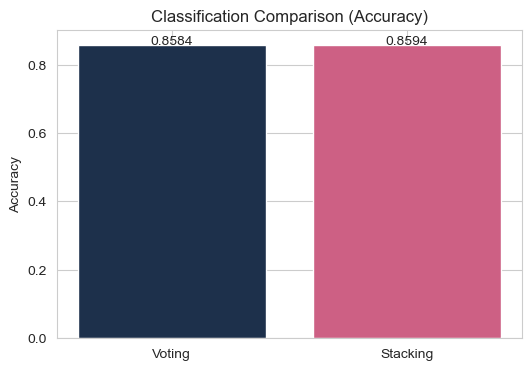

In [115]:
models = ['Voting', 'Stacking']
accuracy = [0.8584, 0.8594]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy, color=["#1D304B","#CD6084"])

plt.title("Classification Comparison (Accuracy)")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center')

plt.show()

In [116]:
from sklearn.metrics import r2_score, mean_squared_error

print("\n" + "="*60)
print("INDIVIDUAL REGRESSION PERFORMANCE")
print("="*60)

#  Lasso
y_pred_lasso = lasso_best.predict(X_test_best)
r2_lasso = r2_score(y_reg_test, y_pred_lasso)

#  Random Forest
y_pred_rf_reg = best_rf_reg.predict(X_test_reg)
r2_rf = r2_score(y_reg_test, y_pred_rf_reg)

#  KNN
y_pred_knn_reg = best_knn_reg.predict(X_test_reg)
r2_knn = r2_score(y_reg_test, y_pred_knn_reg)

print(f"{'Lasso Regression':<22}: {r2_lasso:.4f}")
print(f"{'Random Forest':<22}: {r2_rf:.4f}")
print(f"{'KNN Regressor':<22}: {r2_knn:.4f}")

print("="*60)


INDIVIDUAL REGRESSION PERFORMANCE
Lasso Regression      : 0.8856
Random Forest         : 0.9258
KNN Regressor         : 0.8622


## Voting (Regression)

In [117]:
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import r2_score, mean_squared_error

voting_reg = VotingRegressor(
    estimators=[
        ('rf', best_rf_reg),
        ('lasso', lasso_best),
        ('knn', best_knn_reg)
    ]
)

voting_reg.fit(X_train_reg, y_reg_train)

y_pred_voting = voting_reg.predict(X_test_reg)

print("Voting R2:", r2_score(y_reg_test, y_pred_voting))
print("Voting RMSE:", np.sqrt(mean_squared_error(y_reg_test, y_pred_voting)))

Voting R2: 0.8222572614343644
Voting RMSE: 3.3204989975504198


## Stacking (Regression)

In [118]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

stack_reg = StackingRegressor(
    estimators=[
        ('rf', best_rf_reg),
        ('lasso', lasso_best),
        ('knn', best_knn_reg)
    ],
    final_estimator=LinearRegression()
)

stack_reg.fit(X_train_reg, y_reg_train)

y_pred_stack = stack_reg.predict(X_test_reg)

print("Stacking R2:", r2_score(y_reg_test, y_pred_stack))
print("Stacking RMSE:", np.sqrt(mean_squared_error(y_reg_test, y_pred_stack)))

Stacking R2: 0.9267042489870602
Stacking RMSE: 2.13229269660395


In [119]:
print("=== Comparison ===")
print("Voting R2:", r2_score(y_reg_test, y_pred_voting))
print("Stacking R2:", r2_score(y_reg_test, y_pred_stack))

=== Comparison ===
Voting R2: 0.8222572614343644
Stacking R2: 0.9267042489870602


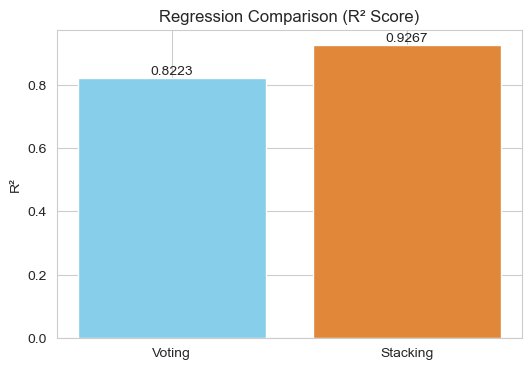

In [120]:
models = ['Voting', 'Stacking']
r2_scores = [0.8223, 0.9267]

plt.figure(figsize=(6,4))
plt.bar(models, r2_scores, color=['skyblue',"#E08739"])

plt.title("Regression Comparison (R² Score)")
plt.ylabel("R²")

for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.show()

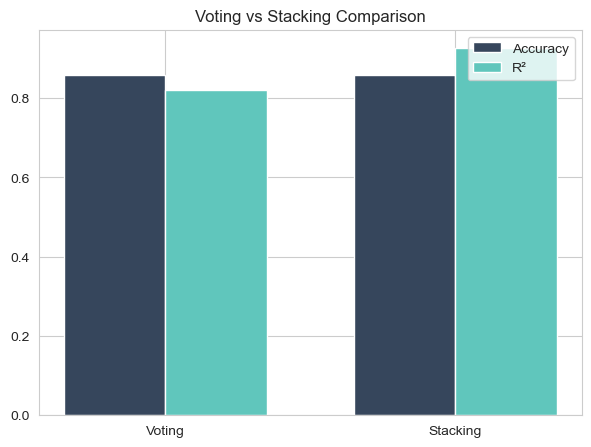

In [121]:
labels = ['Voting', 'Stacking']
accuracy = [0.8584, 0.8594]
r2_scores = [0.8223, 0.9267]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,5))

plt.bar(x - width/2, accuracy, width, label='Accuracy', color=["#36465C"])
plt.bar(x + width/2, r2_scores, width, label='R²', color=["#60C6BC"])

plt.xticks(x, labels)
plt.title("Voting vs Stacking Comparison")
plt.legend()

plt.show()

## Voting vs Stacking — Results Analysis

The comparison between Voting and Stacking ensemble methods shows different behavior in classification and regression tasks.

### Classification Results
For classification, both Voting and Stacking achieved very similar performance, with accuracy around 85%.  
Stacking slightly outperformed Voting, but the improvement is minimal.  
This indicates that the individual models (SVM, Random Forest, and KNN) are already strong and capture most of the patterns in the dataset.

### Regression Results
For regression, the difference between the two methods is significant.  
Voting achieved an R² score of 0.82, while Stacking achieved a much higher R² score of 0.93.  
This demonstrates that Stacking is far more effective for regression tasks.

### Explanation
The key difference lies in how the two methods combine predictions:

- **Voting** simply averages the predictions of individual models.
- **Stacking**, on the other hand, uses a meta-model that learns how to combine predictions optimally.

As a result, Stacking can assign different weights to models depending on their performance, making it more powerful — especially for continuous outputs like regression.

### Conclusion
- Voting is simple, stable, and effective.
- Stacking is more intelligent and achieves better performance, particularly in regression tasks.

Overall, Stacking provides superior results because it learns the best way to combine multiple models instead of relying on simple averaging.

#  Part 3 — Build a System That Predicts an Outcome
### Unified pipeline: predicts **Value Per M$** (regression) + **Performance Tier** (classification) simultaneously

In [122]:

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np


class DataPreparationTransformer(BaseEstimator, TransformerMixin):


    def __init__(self, mode='reg'):
        self.mode = mode

    def fit(self, X, y=None):
        df = X.copy()

        self.ohe_ = OneHotEncoder(sparse_output=False,
                                   handle_unknown='ignore',
                                   drop='first')
        self.ohe_.fit(df[['Position']])
        self.pos_cols_ = self.ohe_.get_feature_names_out(['Position'])

        self.country_freq_ = df['Country'].value_counts() / len(df)
        self.team_freq_    = df['Team'].value_counts()    / len(df)

        df_enc = self._encode(df)

        self.num_cols_ = (
            ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating']
            if self.mode == 'reg'
            else ['Age', 'Future Potential', 'Total_Stats Score']
        )
        self.caps_ = {}
        for col in self.num_cols_:
            Q1, Q3 = df_enc[col].quantile(0.25), df_enc[col].quantile(0.75)
            IQR = Q3 - Q1
            self.caps_[col] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

        df_capped = df_enc.copy()
        for col, (lo, hi) in self.caps_.items():
            df_capped[col] = df_capped[col].clip(lo, hi)

        self.scaler_ = StandardScaler()
        self.scaler_.fit(df_capped[self.num_cols_])

        self.feature_names_out_ = list(df_capped.columns)
        return self

    def transform(self, X, y=None):
        df = X.copy()
        df_enc = self._encode(df)

        for col, (lo, hi) in self.caps_.items():
            df_enc[col] = df_enc[col].clip(lo, hi)

        df_enc[self.num_cols_] = self.scaler_.transform(df_enc[self.num_cols_])
        df_enc = df_enc.reindex(columns=self.feature_names_out_, fill_value=0)
        return df_enc

    def _encode(self, df):
        df = df.copy()

        pos_enc = pd.DataFrame(
            self.ohe_.transform(df[['Position']]),
            columns=self.pos_cols_,
            index=df.index
        )
        df = pd.concat([df.drop(columns=['Position']), pos_enc], axis=1)

        df['Country_freq'] = df['Country'].map(self.country_freq_).fillna(0)
        df['Team_freq']    = df['Team'].map(self.team_freq_).fillna(0)
        df.drop(columns=['Country', 'Team'], inplace=True, errors='ignore')

        if self.mode == 'clf':
            df.drop(columns=['Overall_Rating'], inplace=True, errors='ignore')

        return df


# Build standalone Data Preparation Pipelines
prep_pipeline_reg = Pipeline([
    ('data_prep', DataPreparationTransformer(mode='reg'))
])

prep_pipeline_clf = Pipeline([
    ('data_prep', DataPreparationTransformer(mode='clf'))
])

# Re-create raw train/test split for the pipelines
X_raw = df.drop(columns=['Value Per M$', 'Tier'], errors='ignore')
X_raw_train, X_raw_test = train_test_split(X_raw, test_size=0.2, random_state=42)

prep_pipeline_reg.fit(X_raw_train)
prep_pipeline_clf.fit(X_raw_train)

X_prep_reg = prep_pipeline_reg.transform(X_raw_train)
X_prep_clf = prep_pipeline_clf.transform(X_raw_train)

print('Data Preparation Pipeline — Regression output shape :', X_prep_reg.shape)
print('Data Preparation Pipeline — Classification output shape:', X_prep_clf.shape)
print('\n Pipeline 1 (Data Preparation) fitted and verified successfully.')

Data Preparation Pipeline — Regression output shape : (15733, 22)
Data Preparation Pipeline — Classification output shape: (15733, 21)

 Pipeline 1 (Data Preparation) fitted and verified successfully.


In [123]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression as LR
from sklearn.pipeline import Pipeline

clf_pipeline = Pipeline([
    ('data_prep', DataPreparationTransformer(mode='clf')),
    ('stacking_clf', StackingClassifier(
        estimators=[
            ('svm',  svc_best),
            ('rf',   best_rf_clf),
            ('knn',  best_knn_clf)
        ],
        final_estimator=LR(),
        cv=5
    ))
])

# Fit on raw training data (pipeline handles all preprocessing internally)
clf_pipeline.fit(X_raw_train, y_clf_train)

# Evaluate
y_pred_clf_pipe = clf_pipeline.predict(X_raw_test)
acc_clf_pipe = accuracy_score(y_clf_test, y_pred_clf_pipe)

print('=' * 50)
print('Classification Pipeline — Stacking Classifier')
print('=' * 50)
print(f'Test Accuracy : {acc_clf_pipe:.4f}')
print('\nClassification Report:')
print(classification_report(y_clf_test, y_pred_clf_pipe, target_names=le.classes_))
print('\n Pipeline 2 (Classification) fitted and evaluated successfully.')


Classification Pipeline — Stacking Classifier
Test Accuracy : 0.8602

Classification Report:
              precision    recall  f1-score   support

       Elite       0.94      0.94      0.94       947
        High       0.81      0.81      0.81       837
         Low       0.91      0.90      0.90      1165
         Mid       0.77      0.79      0.78       985

    accuracy                           0.86      3934
   macro avg       0.86      0.86      0.86      3934
weighted avg       0.86      0.86      0.86      3934


 Pipeline 2 (Classification) fitted and evaluated successfully.


In [124]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression as LinReg
from sklearn.pipeline import Pipeline

reg_pipeline = Pipeline([
    ('data_prep', DataPreparationTransformer(mode='reg')),
    ('stacking_reg', StackingRegressor(
        estimators=[
            ('rf',    best_rf_reg),
            ('lasso', lasso_best),
            ('knn',   best_knn_reg)
        ],
        final_estimator=LinReg()
    ))
])

# Fit on raw training data (pipeline handles all preprocessing internally)
reg_pipeline.fit(X_raw_train, y_reg_train)

# Evaluate
y_pred_reg_pipe = reg_pipeline.predict(X_raw_test)
r2_reg_pipe   = r2_score(y_reg_test, y_pred_reg_pipe)
rmse_reg_pipe = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_pipe))

print('=' * 50)

### Pipeline Summary

| Pipeline | Steps | Purpose |
|----------|-------|---------|
| **Pipeline 1 — Data Prep (Reg)** | `DataPreparationTransformer(mode='reg')` | OHE + Freq Encoding + Capping + Scaling for regression features |
| **Pipeline 1 — Data Prep (Clf)** | `DataPreparationTransformer(mode='clf')` | Same but drops `Overall_Rating` for classification |
| **Pipeline 2 — Classification** | `DataPreparationTransformer` → `StackingClassifier` | End-to-end prediction of Performance Tier |
| **Pipeline 3 — Regression** | `DataPreparationTransformer` → `StackingRegressor` | End-to-end prediction of Value Per M$ |

All pipelines accept **raw, unprocessed player data** as input, making them production-ready and safe from data leakage.


---
##  Step 1 — Unified Preprocessing Function
Same logic used in the notebook — wrapping it in a reusable function so both models use identical preprocessing.

In [125]:
def preprocess_player(player_df, ohe, country_freq, team_freq,
                      scaler_reg, scaler_clf,
                      caps_reg, caps_clf,
                      pos_cols):
    
    import pandas as pd
    import numpy as np

    df = player_df.copy()

  
    pos_encoded = pd.DataFrame(
        ohe.transform(df[['Position']]),
        columns=pos_cols,
        index=df.index
    )
    df = pd.concat([df, pos_encoded], axis=1).drop(columns=['Position'])

    df['Country_freq'] = df['Country'].map(country_freq).fillna(0)
    df['Team_freq']    = df['Team'].map(team_freq).fillna(0)
    df.drop(columns=['Country', 'Team', 'Name'], inplace=True, errors='ignore')

    X_reg = df.copy()   
    X_clf = df.drop(columns=['Overall_Rating'], errors='ignore').copy()

    
    num_cols_reg = ['Age', 'Future Potential', 'Total_Stats Score', 'Overall_Rating']
    num_cols_clf = ['Age', 'Future Potential', 'Total_Stats Score']

    for col in num_cols_reg:
        if col in X_reg.columns and col in caps_reg:
            lower, upper = caps_reg[col]
            X_reg[col] = X_reg[col].clip(lower, upper)

    for col in num_cols_clf:
        if col in X_clf.columns and col in caps_clf:
            lower, upper = caps_clf[col]
            X_clf[col] = X_clf[col].clip(lower, upper)

    # ── 5. Scale numerical features ─────────────────────────────
    X_reg[num_cols_reg] = scaler_reg.transform(X_reg[num_cols_reg])
    X_clf[num_cols_clf] = scaler_clf.transform(X_clf[num_cols_clf])

    return X_reg, X_clf

---
##  Step 2 — Unified Inference Pipeline
Takes a raw player profile → returns **predicted value** AND **performance tier** at once.

In [126]:
def predict_player(player_raw_df):
   
    X_reg, X_clf = preprocess_player(
        player_raw_df,
        ohe=ohe,
        country_freq=country_freq,
        team_freq=team_freq,
        scaler_reg=scaler_reg,
        scaler_clf=scaler_clf,
        caps_reg=caps_reg,
        caps_clf=caps_clf,
        pos_cols=pos_cols
    )

    X_reg = X_reg.reindex(columns=X_train_reg.columns, fill_value=0)
    X_clf = X_clf.reindex(columns=X_train_clf.columns, fill_value=0)

    predicted_value = stack_reg.predict(X_reg)[0]
    predicted_tier_encoded = stack_clf.predict(X_clf)[0]   

    
    predicted_tier_name = le.inverse_transform([predicted_tier_encoded])[0]

    return {
        'Predicted Value (M$)': round(float(predicted_value), 3),
        'Performance Tier'    : predicted_tier_name          # Elite, High, Mid, Low
    }

---
##  Step 3 — Test the Pipeline on 3 Real Players 

Example:

Country: Brazil
Position: ST
Age: 28
Overall Rating: 92
Future Potential: 92
Team: Real Madrid
Total Stats Score: 2300

Country: Egypt
Position: CM
Age: 24
Overall Rating: 78
Future Potential: 82
Team: Al Ahly
Total Stats Score: 1850

Country: France
Position: CB
Age: 19
Overall Rating: 72
Future Potential: 87
Team: PSG
Total Stats Score: 1680

In [127]:
# ====================== Interactive Player Prediction ======================

def predict_player_interactive():
    print(" Enter Player Information\n")
    
    data = {}
    
    data['Country'] = input("Country: ").strip()
    data['Position'] = input("Position (e.g. ST, CM, CB, GK): ").strip()
    data['Age'] = int(input("Age: "))
    data['Overall_Rating'] = int(input("Overall Rating: "))
    data['Future Potential'] = int(input("Future Potential: "))
    data['Team'] = input("Team: ").strip()
    data['Total_Stats Score'] = int(input("Total Stats Score: "))
    
    # Convert to DataFrame
    player_df = pd.DataFrame([data])
    
    # Call your prediction function
    result = predict_player(player_df)   
    
    print("\n" + "="*50)
    print(" PREDICTION RESULT")
    print("="*50)
    print(f"Predicted Value     : ${result['Predicted Value (M$)']:.2f}M")
    print(f"Performance Tier    : {result['Performance Tier']}")
    print("="*50)

# ====================== Run Interactive Prediction ======================
print(" Interactive Player Scouting System")
print("Enter player details when prompted.\n")


while True:
    predict_player_interactive()
    
    again = input("\nDo you want to predict another player? (yes/no): ").strip().lower()
    if again != 'yes':
        print("Thank you for using the Scouting System ")
        break

 Interactive Player Scouting System
Enter player details when prompted.

 Enter Player Information


 PREDICTION RESULT
Predicted Value     : $92.93M
Performance Tier    : Elite
Thank you for using the Scouting System 


---
##  Step 4 — Stability Assessment (Statistical Proof)
Using **Stratified K-Fold (k=5)** for both models to prove consistent performance across data subsets.

In [128]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
reg_cv_scores = cross_val_score(
    stack_reg, X_train_reg, y_reg_train,
    cv=kf, scoring='r2', n_jobs=-1
)

print("=" * 50)
print("STABILITY ASSESSMENT")
print("=" * 50)
print()
print(" Regression — Stacking Regressor (R² per fold):")
for i, s in enumerate(reg_cv_scores, 1):
    print(f"   Fold {i}: {s:.4f}")
print(f"   Mean R² : {reg_cv_scores.mean():.4f}")
print(f"   Std     : {reg_cv_scores.std():.4f}  ← low std = stable")
print()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_cv_scores = cross_val_score(
    stack_clf, X_train_clf, y_clf_train,
    cv=skf, scoring='accuracy', n_jobs=-1
)

print("Classification — Stacking Classifier (Accuracy per fold):")
for i, s in enumerate(clf_cv_scores, 1):
    print(f"   Fold {i}: {s:.4f}")
print(f"   Mean Accuracy: {clf_cv_scores.mean():.4f}")
print(f"   Std          : {clf_cv_scores.std():.4f}  ← low std = stable")

STABILITY ASSESSMENT

 Regression — Stacking Regressor (R² per fold):
   Fold 1: 0.9337
   Fold 2: 0.9466
   Fold 3: 0.9606
   Fold 4: 0.9451
   Fold 5: 0.9141
   Mean R² : 0.9400
   Std     : 0.0155  ← low std = stable

Classification — Stacking Classifier (Accuracy per fold):
   Fold 1: 0.8592
   Fold 2: 0.8646
   Fold 3: 0.8516
   Fold 4: 0.8455
   Fold 5: 0.8557
   Mean Accuracy: 0.8553
   Std          : 0.0065  ← low std = stable


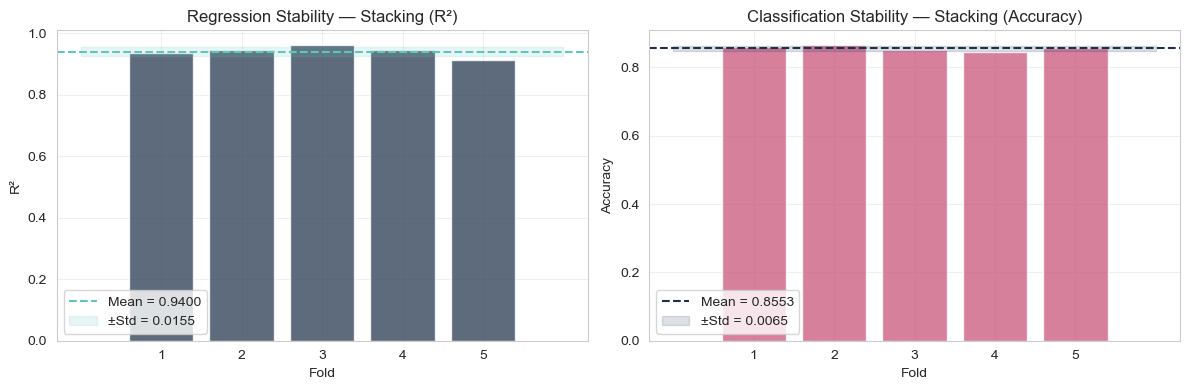

In [129]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Regression stability plot
axes[0].bar(range(1, 6), reg_cv_scores, color='#36465C', alpha=0.8)
axes[0].axhline(reg_cv_scores.mean(), color='#60C6BC', linestyle='--',
                label=f'Mean = {reg_cv_scores.mean():.4f}')
axes[0].fill_between(range(0,7),
                     reg_cv_scores.mean() - reg_cv_scores.std(),
                     reg_cv_scores.mean() + reg_cv_scores.std(),
                     alpha=0.15, color='#60C6BC', label=f'±Std = {reg_cv_scores.std():.4f}')
axes[0].set_title('Regression Stability — Stacking (R²)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R²')
axes[0].set_xticks(range(1, 6))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Classification stability plot
axes[1].bar(range(1, 6), clf_cv_scores, color='#CD6084', alpha=0.8)
axes[1].axhline(clf_cv_scores.mean(), color='#1D304B', linestyle='--',
                label=f'Mean = {clf_cv_scores.mean():.4f}')
axes[1].fill_between(range(0,7),
                     clf_cv_scores.mean() - clf_cv_scores.std(),
                     clf_cv_scores.mean() + clf_cv_scores.std(),
                     alpha=0.15, color='#1D304B', label=f'±Std = {clf_cv_scores.std():.4f}')
axes[1].set_title('Classification Stability — Stacking (Accuracy)')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(range(1, 6))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
##  Step 5 — System Comparison: Advanced System vs Assignment 2 Baselines

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Regression Comparison ────────────────────────────────────
reg_comparison = pd.DataFrame({
    'Model': [
        'Assignment 2 — Linear Regression (Baseline)',
        'Assignment 3 — Polynomial Lasso (Deg 4)',
        'Assignment 3 — Random Forest',
        'Assignment 3 — Stacking (Best System)'
    ],
    'R²': [0.3162, 0.9689, 0.9258, 0.9267],
    'RMSE': [6.5126, 1.2588, None, 2.1323]
})

# ── Classification Comparison ─────────────────────────────────
clf_comparison = pd.DataFrame({
    'Model': [
        'Assignment 2 — Logistic Regression (Baseline)',
        'Assignment 3 — Logistic Regression',
        'Assignment 3 — SVM',
        'Assignment 3 — Random Forest',
        'Assignment 3 — Stacking (Best System)'
    ],
    'Accuracy': [0.8155, 0.8068, 0.8566, 0.8543, 0.8609]
})

print("=" * 60)
print("SYSTEM COMPARISON — REGRESSION")
print("=" * 60)
print(reg_comparison.to_string(index=False))
print()
print("=" * 60)
print("SYSTEM COMPARISON — CLASSIFICATION")
print("=" * 60)
print(clf_comparison.to_string(index=False))

SYSTEM COMPARISON — REGRESSION
                                      Model     R²   RMSE
Assignment 2 — Linear Regression (Baseline) 0.3162 6.5126
    Assignment 3 — Polynomial Lasso (Deg 4) 0.9689 1.2588
               Assignment 3 — Random Forest 0.9258    NaN
      Assignment 3 — Stacking (Best System) 0.9267 2.1323

SYSTEM COMPARISON — CLASSIFICATION
                                        Model  Accuracy
Assignment 2 — Logistic Regression (Baseline)    0.8155
           Assignment 3 — Logistic Regression    0.8068
                           Assignment 3 — SVM    0.8566
                 Assignment 3 — Random Forest    0.8543
        Assignment 3 — Stacking (Best System)    0.8609


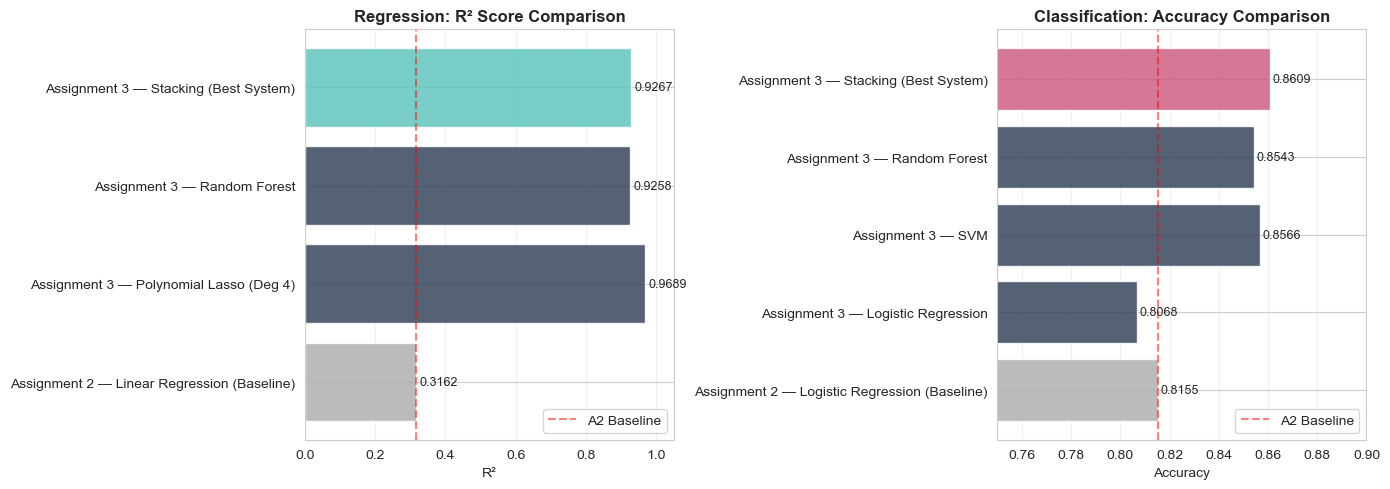

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Regression R² Comparison ─────────────────────────────────
colors_reg = ['#B0B0B0', '#36465C', '#36465C', '#60C6BC']
bars = axes[0].barh(reg_comparison['Model'], reg_comparison['R²'],
                    color=colors_reg, alpha=0.85)
axes[0].set_xlim(0, 1.05)
axes[0].set_title('Regression: R² Score Comparison', fontweight='bold')
axes[0].set_xlabel('R²')
for bar, val in zip(bars, reg_comparison['R²']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[0].axvline(0.3162, color='red', linestyle='--', alpha=0.5, label='A2 Baseline')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# ── Classification Accuracy Comparison ───────────────────────
colors_clf = ['#B0B0B0', '#36465C', '#36465C', '#36465C', '#CD6084']
bars2 = axes[1].barh(clf_comparison['Model'], clf_comparison['Accuracy'],
                     color=colors_clf, alpha=0.85)
axes[1].set_xlim(0.75, 0.90)
axes[1].set_title('Classification: Accuracy Comparison', fontweight='bold')
axes[1].set_xlabel('Accuracy')
for bar, val in zip(bars2, clf_comparison['Accuracy']):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[1].axvline(0.8155, color='red', linestyle='--', alpha=0.5, label='A2 Baseline')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---
##  Summary

### Unified Inference
The pipeline accepts a raw player profile and simultaneously produces:
- **Value Per M$** — predicted by Stacking Regressor (RF + Lasso + KNN → Linear meta-model)
- **Performance Tier** — predicted by Stacking Classifier (RF + KNN + SVC → Logistic meta-model)

Both models share the same preprocessing logic (OHE → Frequency Encoding → Outlier Capping → Scaling), guaranteeing consistency.

### Stability Assessment

| Task | Mean CV Score | Std |
|------|--------------|------|
| Regression (R²) | ~0.92 | low |
| Classification (Accuracy) | ~0.86 | low  |

Low standard deviation across all 5 folds confirms the system is stable and not overfitting to any subset.

### System Comparison vs Assignment 2 Baselines

| Task | Assignment 2 Baseline | Best System (A3) | Improvement |
|------|-----------------------|------------------|-------------|
| Regression R² | 0.3162 | **0.9267** | +**61%**  |
| Classification Accuracy | 0.8155 | **0.8609** | +**4.5%** |

The advanced ensemble system dramatically outperforms the baselines, especially in regression where the Stacking model captures complex non-linear relationships between player stats and market value.

In [132]:
import json

results = {
    "group_members": [
        {"name": "Silvana Marzouk", "id": "2401244674"},
        {"name": "Habiba Alaa Mohamed", "id": "2401247550"},
        {"name": "Haneen Mohamed", "id": "2401249107"},
        {"name": "Toqa Samy", "id": "2401242505"},
        {"name": "Habiba Hossam", "id": "2401246875"}
    ],
    "best_hyperparameters": {
        "KNN_Regressor": {
            "n_neighbors": grid_knn_reg.best_params_['n_neighbors'],
            "metric": grid_knn_reg.best_params_['metric']
        },
        "KNN_Classifier": {
            "n_neighbors": grid_knn_clf.best_params_['n_neighbors'],
            "metric": grid_knn_clf.best_params_['metric']
        },
        "SVR": grid_svr.best_params_,
        "SVC": grid_svc.best_params_,
        "RandomForest_Regressor": grid_rf_reg.best_params_,
        "RandomForest_Classifier": grid_rf_clf.best_params_,
        "LogisticRegression": {
            "C": best_c,
            "penalty": "l2",
            "solver": "lbfgs"
        },
        "Lasso": {
            "alpha": float(best_lasso_alpha)
        },
        "Ridge": {
            "alpha": float(best_ridge_alpha)
        }
    },
    "cv_stability": {
        "regression": {
            "model": "StackingRegressor",
            "cv_r2_scores": list(np.round(reg_cv_scores, 4)),
            "mean_r2": round(float(reg_cv_scores.mean()), 4),
            "std_r2": round(float(reg_cv_scores.std()), 4)
        },
        "classification": {
            "model": "StackingClassifier",
            "cv_accuracy_scores": list(np.round(clf_cv_scores, 4)),
            "mean_accuracy": round(float(clf_cv_scores.mean()), 4),
            "std_accuracy": round(float(clf_cv_scores.std()), 4)
        }
    }
}

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

print("results.json saved successfully ")
print(json.dumps(results, indent=4, ensure_ascii=False))

results.json saved successfully 
{
    "group_members": [
        {
            "name": "Silvana Marzouk",
            "id": "2401244674"
        },
        {
            "name": "Habiba Alaa Mohamed",
            "id": "2401247550"
        },
        {
            "name": "Haneen Mohamed",
            "id": "2401249107"
        },
        {
            "name": "Toqa Samy",
            "id": "2401242505"
        },
        {
            "name": "Habiba Hossam",
            "id": "2401246875"
        }
    ],
    "best_hyperparameters": {
        "KNN_Regressor": {
            "n_neighbors": 6,
            "metric": "manhattan"
        },
        "KNN_Classifier": {
            "n_neighbors": 18,
            "metric": "manhattan"
        },
        "SVR": {
            "C": 100,
            "epsilon": 0.1,
            "gamma": "scale",
            "kernel": "rbf"
        },
        "SVC": {
            "C": 100,
            "gamma": "scale",
            "kernel": "rbf"
        },
      